In [1]:
# Build segments, apply cleaning, and export the dataset.
# This version follows the final thesis settings agreed with the supervisor.
# This notebook runs on block 1 only.
# This variant uses the theta band from 4 to 8 Hz only.
# Load the STIM_TOL_S, DC_TAIL_S, and STFT configs automatically.
# Keep DC detection aligned with the DC tail notebook.
# Scan only the VHDR files in this block 1 folder.
# Save outputs for thesis traceability.
# Use the same cleaning, split logic, and pipeline as the baseline run.
# Restrict only the input frequency band to theta.

import os
import re
import json
import glob
import pickle
from math import gcd
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import mne
from scipy import signal

mne.set_log_level("ERROR")


# Notebook variant
RUN_VARIANT = "block1_theta"


# Set the main paths.
# This notebook runs on block 1 only.
# Set RAW_DIR to the folder that contains the block 1 .VHDR files.
RAW_DIR = r"C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 1"

# Important note.
# Use a separate OUT_DIR for the theta only experiment so it does not overwrite.
# The baseline full band outputs.
OUT_DIR = r"D:\EEG_CleanSegments_And_Datasets_block1_theta"
os.makedirs(OUT_DIR, exist_ok=True)

# Important note.
# Load the configs from the original baseline directory,.
# So the cleaning thresholds stay the same and only the frequency band changes.
CONFIG_DIR = r"D:\EEG_CleanSegments_And_Datasets"

# Search only inside this folder without recursion.
VHDR_GLOB = os.path.join(RAW_DIR, "*.vhdr")


# Sampling and filtering
TARGET_SFREQ = 250.0

# Use the theta band requested by the supervisor.
BANDPASS_LO = 4.0
BANDPASS_HI = 8.0
FILTER_ORDER = 4

KEEP_CHANNELS = None   # None > keep all EEG channels.


# Expected task stimulus length.
EPOCH_LEN_S = 4.5
EPOCH_LEN_SAMPLES = int(round(EPOCH_LEN_S * TARGET_SFREQ))


# Default config values
# Use these only if the config files are missing.
DEFAULT_STIM_TOL_S = 0.50
DEFAULT_DC_MIN_S = 0.05
DEFAULT_DC_TAIL_S = 2.10

DEFAULT_STFT_WINDOW = "hann"
DEFAULT_STFT_NPERSEG_S = 3.0
DEFAULT_STFT_OVERLAP_S = 2.8
DEFAULT_STFT_NFFT_MULT = 4
DEFAULT_STFT_MAX_FREQ_HZ = 40.0


# Set the config paths.
STIM_TOL_CONFIG_PATH = os.path.join(CONFIG_DIR, "STIM_TOL_S_recommended.json")
DC_MIN_CONFIG_PATH = os.path.join(CONFIG_DIR, "DC_MIN_S_recommended.json")
DC_TAIL_CONFIG_PATH = os.path.join(CONFIG_DIR, "DC_TAIL_S_recommended.json")
STFT_CONFIG_PATH = os.path.join(CONFIG_DIR, "STFT_recommended.json")


# Set the STFT parameters.
# These are overwritten if a saved config is available.
STFT_WINDOW = DEFAULT_STFT_WINDOW
STFT_NPERSEG_S = DEFAULT_STFT_NPERSEG_S
STFT_OVERLAP_S = DEFAULT_STFT_OVERLAP_S
STFT_NFFT_MULT = DEFAULT_STFT_NFFT_MULT
STFT_MAX_FREQ_HZ = DEFAULT_STFT_MAX_FREQ_HZ


# Define the label mapping.
# Three class targets
CODES_MAP = {
    "S11": 0,     # Left real stimulus.
    "S110": 0,    # Left sham stimulus.
    "S12": 1,     # Right real stimulus.
    "S120": 1,    # Right sham stimulus.
    "S13": 2,     # No stimulus.
}

# Fine labels for the task stimuli
FINE_LABELS_MAP = {
    "S11": "stim_left_real",
    "S110": "stim_left_fake",
    "S12": "stim_right_real",
    "S120": "stim_right_fake",
    "S13": "stim_no",
}
TASK_FINE_LABELS = set(FINE_LABELS_MAP.values())

# TMS markers
TMS_CODES = {"S114", "S124", "S134"}


# Define the annotation patterns.
NEW_SEG_PATTERN = re.compile(r"^new\s*segment/?", re.IGNORECASE)
STIM_PATTERN = re.compile(r"^stimulus/", re.IGNORECASE)
STIM_CODE_RE = re.compile(r"^Stimulus/\s*(S)\s*([0-9]+)\s*$", re.IGNORECASE)

# Keep DC detection aligned with the DC tail estimation notebook.
DC_PATTERN = re.compile(
    r"\bDC\b|DC\s*Correction|DCC|DC-corr|DC\s*correction/",
    re.IGNORECASE
)


# Set the cleaning flags.
APPLY_DC_TAIL_RULE = True
DROP_STIM_WITHIN_DC_TAIL = True

# Keep these only for explicit backward compatible ablations if they are ever needed.
DROP_SEGMENT_AFTER_SHORT_DC = False
DROP_TMS_SEGMENTS = True
DROP_SEGMENT_AFTER_TMS_CONDITIONALLY = False
TMS_ABS_SHORT_S = 0.50


# Config loaders
def _load_json_or_empty(path: str, label: str) -> dict:
    try:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                cfg = json.load(f)
            print(f"[{label}] loaded config: {path}")
            return cfg
        else:
            print(f"[{label}] config not found -> using defaults | expected: {path}")
            return {}
    except Exception as e:
        print(f"[{label}] failed to read config ({e}) -> using defaults")
        return {}

def _cfg_float_from_keys(cfg: dict, candidate_keys: List[str], default: float) -> float:
    try:
        for k in candidate_keys:
            if k in cfg and cfg[k] is not None:
                return float(cfg[k])
    except Exception:
        pass
    return float(default)

def _cfg_int_from_keys(cfg: dict, candidate_keys: List[str], default: int) -> int:
    try:
        for k in candidate_keys:
            if k in cfg and cfg[k] is not None:
                return int(cfg[k])
    except Exception:
        pass
    return int(default)

def _cfg_str_from_keys(cfg: dict, candidate_keys: List[str], default: str) -> str:
    try:
        for k in candidate_keys:
            if k in cfg and cfg[k] is not None:
                return str(cfg[k])
    except Exception:
        pass
    return str(default)

def _sanitize_positive_float(x: float, default: float, name: str) -> float:
    try:
        x = float(x)
        if np.isfinite(x) and x > 0:
            return x
    except Exception:
        pass
    print(f"[CONFIG] invalid {name} -> using default {default}")
    return float(default)

def _sanitize_nonnegative_float(x: float, default: float, name: str) -> float:
    try:
        x = float(x)
        if np.isfinite(x) and x >= 0:
            return x
    except Exception:
        pass
    print(f"[CONFIG] invalid {name} -> using default {default}")
    return float(default)

def _sanitize_positive_int(x: int, default: int, name: str) -> int:
    try:
        x = int(x)
        if x >= 1:
            return x
    except Exception:
        pass
    print(f"[CONFIG] invalid {name} -> using default {default}")
    return int(default)


# Load the configs.
_stim_cfg = _load_json_or_empty(STIM_TOL_CONFIG_PATH, label="STIM_TOL_S")
_dcmin_cfg = _load_json_or_empty(DC_MIN_CONFIG_PATH, label="DC_MIN_S")
_dctail_cfg = _load_json_or_empty(DC_TAIL_CONFIG_PATH, label="DC_TAIL_S")
_stft_cfg = _load_json_or_empty(STFT_CONFIG_PATH, label="STFT")

# Numeric cleaning thresholds
STIM_TOL_S = _cfg_float_from_keys(
    _stim_cfg,
    candidate_keys=["STIM_TOL_S", "recommended_STIM_TOL_S"],
    default=DEFAULT_STIM_TOL_S
)
STIM_TOL_S = _sanitize_nonnegative_float(STIM_TOL_S, DEFAULT_STIM_TOL_S, "STIM_TOL_S")

DC_MIN_S = _cfg_float_from_keys(
    _dcmin_cfg,
    candidate_keys=["DC_MIN_S", "recommended_DC_MIN_S"],
    default=DEFAULT_DC_MIN_S
)
DC_MIN_S = _sanitize_nonnegative_float(DC_MIN_S, DEFAULT_DC_MIN_S, "DC_MIN_S")

DC_TAIL_S = _cfg_float_from_keys(
    _dctail_cfg,
    candidate_keys=["DC_TAIL_S", "recommended_dc_tail_s"],
    default=DEFAULT_DC_TAIL_S
)
DC_TAIL_S = _sanitize_positive_float(DC_TAIL_S, DEFAULT_DC_TAIL_S, "DC_TAIL_S")

# Set the STFT parameters.
STFT_WINDOW = _cfg_str_from_keys(
    _stft_cfg,
    candidate_keys=["STFT_WINDOW"],
    default=DEFAULT_STFT_WINDOW
)

STFT_NPERSEG_S = _cfg_float_from_keys(
    _stft_cfg,
    candidate_keys=["STFT_NPERSEG_S"],
    default=DEFAULT_STFT_NPERSEG_S
)
STFT_NPERSEG_S = _sanitize_positive_float(STFT_NPERSEG_S, DEFAULT_STFT_NPERSEG_S, "STFT_NPERSEG_S")

STFT_OVERLAP_S = _cfg_float_from_keys(
    _stft_cfg,
    candidate_keys=["STFT_OVERLAP_S"],
    default=DEFAULT_STFT_OVERLAP_S
)
STFT_OVERLAP_S = _sanitize_nonnegative_float(STFT_OVERLAP_S, DEFAULT_STFT_OVERLAP_S, "STFT_OVERLAP_S")

STFT_NFFT_MULT = _cfg_int_from_keys(
    _stft_cfg,
    candidate_keys=["STFT_NFFT_MULT"],
    default=DEFAULT_STFT_NFFT_MULT
)
STFT_NFFT_MULT = _sanitize_positive_int(STFT_NFFT_MULT, DEFAULT_STFT_NFFT_MULT, "STFT_NFFT_MULT")

STFT_MAX_FREQ_HZ = _cfg_float_from_keys(
    _stft_cfg,
    candidate_keys=["STFT_MAX_FREQ_HZ"],
    default=DEFAULT_STFT_MAX_FREQ_HZ
)
STFT_MAX_FREQ_HZ = _sanitize_positive_float(STFT_MAX_FREQ_HZ, DEFAULT_STFT_MAX_FREQ_HZ, "STFT_MAX_FREQ_HZ")

# Extra STFT sanity checks
if STFT_OVERLAP_S >= STFT_NPERSEG_S:
    safe_overlap = max(0.0, STFT_NPERSEG_S - (1.0 / TARGET_SFREQ))
    print(f"[CONFIG] STFT_OVERLAP_S >= STFT_NPERSEG_S -> clipping overlap from {STFT_OVERLAP_S:.4f} to {safe_overlap:.4f}")
    STFT_OVERLAP_S = safe_overlap

target_nyquist = TARGET_SFREQ / 2.0
if STFT_MAX_FREQ_HZ > target_nyquist:
    print(f"[CONFIG] STFT_MAX_FREQ_HZ > Nyquist({target_nyquist:.1f}) -> clipping")
    STFT_MAX_FREQ_HZ = float(target_nyquist)

EPOCH_MIN_S = EPOCH_LEN_S - STIM_TOL_S
EPOCH_MAX_S = EPOCH_LEN_S + STIM_TOL_S

print(f"[CONFIG] RUN_VARIANT={RUN_VARIANT}")
print(f"[CONFIG] EPOCH_LEN_S={EPOCH_LEN_S:.3f} | STIM_TOL_S={STIM_TOL_S:.3f} -> valid stimulus range = [{EPOCH_MIN_S:.3f}, {EPOCH_MAX_S:.3f}]")
print(f"[CONFIG] DC_MIN_S={DC_MIN_S:.3f} | DC_TAIL_S={DC_TAIL_S:.3f}")
print(f"[CONFIG] BANDPASS={BANDPASS_LO:.1f}-{BANDPASS_HI:.1f} Hz")
print(f"[CONFIG] STFT_WINDOW={STFT_WINDOW} | STFT_NPERSEG_S={STFT_NPERSEG_S:.3f} | STFT_OVERLAP_S={STFT_OVERLAP_S:.3f} | STFT_NFFT_MULT={STFT_NFFT_MULT} | STFT_MAX_FREQ_HZ={STFT_MAX_FREQ_HZ:.1f}")


# Data structures
@dataclass
class SegmentMeta:
    subject: str
    block_id: str
    recording_id: str
    file_path: str

    order: int

    start_sample: int
    end_sample: int
    n_samples: int
    duration_s: float

    raw_desc: str
    prev_raw_desc: str
    next_raw_desc: str
    fine_label: str

    start_time_s: float = 0.0
    end_time_s: float = 0.0
    next_start_time_s: float = 0.0


# Identity helpers
def parse_recording_identity(vhdr_path: str) -> Tuple[str, str, str]:
    """
    Expects filenames like: 02gd_block1.vhdr
    Returns: subject_id, block_id, recording_id(stem)
    """
    stem = os.path.splitext(os.path.basename(vhdr_path))[0]
    m = re.search(r"(?P<subject>.+?)_block(?P<block>\d+)", stem, flags=re.IGNORECASE)
    if m:
        return m.group("subject"), m.group("block"), stem
    return stem, "unknown", stem


# Event and annotation helpers
def _norm_desc(desc: str) -> str:
    return (desc or "").strip()

def is_new_segment(desc: str) -> bool:
    return bool(NEW_SEG_PATTERN.match(_norm_desc(desc)))

def is_dc(desc: str) -> bool:
    return bool(DC_PATTERN.search(_norm_desc(desc)))

def is_stim(desc: str) -> bool:
    return bool(STIM_PATTERN.match(_norm_desc(desc)))

def parse_stim_code(desc: str) -> Optional[str]:
    m = STIM_CODE_RE.match(_norm_desc(desc))
    if not m:
        return None
    return f"{m.group(1).upper()}{m.group(2)}"

def is_tms(desc: str) -> bool:
    if not is_stim(desc):
        return False
    code = parse_stim_code(desc)
    return code in TMS_CODES

def is_task_stimulus(desc: str) -> bool:
    if not is_stim(desc):
        return False
    code = parse_stim_code(desc)
    return code in CODES_MAP

def is_tms_label(fine_label: str) -> bool:
    return (fine_label or "").startswith("tms_")

def tms_fine_label(tms_code: str, prev_task_code: Optional[str]) -> str:
    if tms_code == "S134":
        return "tms_no"

    if tms_code == "S114":
        if prev_task_code == "S11":
            return "tms_left_real"
        if prev_task_code == "S110":
            return "tms_left_fake"
        return "tms_left_unknown"

    if tms_code == "S124":
        if prev_task_code == "S12":
            return "tms_right_real"
        if prev_task_code == "S120":
            return "tms_right_fake"
        return "tms_right_unknown"

    return "tms_unknown"


# Robust BrainVision reader
def _read_vhdr_refs(vhdr_path: str) -> Tuple[Optional[str], Optional[str]]:
    data_ref, marker_ref = None, None
    with open(vhdr_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            low = line.strip().lower()
            if low.startswith("datafile="):
                data_ref = line.split("=", 1)[1].strip().strip('"')
            elif low.startswith("markerfile="):
                marker_ref = line.split("=", 1)[1].strip().strip('"')
    return data_ref, marker_ref

def _try_candidates(paths: List[str]) -> Optional[str]:
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def _resolve_sidecar(vhdr_path: str, ref: Optional[str], exts: List[str]) -> Optional[str]:
    vhdr_dir = os.path.dirname(vhdr_path)
    stem = os.path.splitext(os.path.basename(vhdr_path))[0]
    raw_parent = os.path.dirname(RAW_DIR)

    candidates: List[str] = []

    if ref:
        if os.path.isabs(ref):
            candidates.extend([
                ref,
                os.path.join(vhdr_dir, os.path.basename(ref)),
                os.path.join(RAW_DIR, os.path.basename(ref)),
                os.path.join(raw_parent, os.path.basename(ref)),
            ])
        else:
            candidates.extend([
                os.path.join(vhdr_dir, ref),
                os.path.join(RAW_DIR, ref),
                os.path.join(raw_parent, ref),
                os.path.join(vhdr_dir, os.path.basename(ref)),
                os.path.join(RAW_DIR, os.path.basename(ref)),
                os.path.join(raw_parent, os.path.basename(ref)),
            ])

    for ext in exts:
        candidates.extend([
            os.path.join(vhdr_dir, stem + ext),
            os.path.join(RAW_DIR, stem + ext),
            os.path.join(raw_parent, stem + ext),
        ])

    found = _try_candidates(candidates)
    if found:
        return found

    for root in [vhdr_dir, RAW_DIR, raw_parent]:
        try:
            for fn in os.listdir(root):
                if fn.lower().startswith(stem.lower()) and any(fn.lower().endswith(ext.lower()) for ext in exts):
                    p = os.path.join(root, fn)
                    if os.path.exists(p):
                        return p
        except Exception:
            pass

    return None

def safe_read_raw_brainvision(vhdr_path: str, preload: bool = False) -> Optional[mne.io.BaseRaw]:
    try:
        return mne.io.read_raw_brainvision(vhdr_path, preload=preload, verbose=False)
    except Exception as e:
        data_ref, marker_ref = _read_vhdr_refs(vhdr_path)
        data_path = _resolve_sidecar(vhdr_path, data_ref, exts=[".eeg", ".dat"])
        marker_path = _resolve_sidecar(vhdr_path, marker_ref, exts=[".vmrk"])

        if data_path is None or marker_path is None:
            print(f"[SKIP] {os.path.basename(vhdr_path)} | cannot resolve sidecars | {type(e).__name__}: {e}")
            return None

        fixed_dir = os.path.join(OUT_DIR, "_vhdr_fixed")
        os.makedirs(fixed_dir, exist_ok=True)
        fixed_vhdr = os.path.join(fixed_dir, os.path.basename(vhdr_path))

        fixed_lines: List[str] = []
        with open(vhdr_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                low = line.strip().lower()
                if low.startswith("datafile="):
                    fixed_lines.append(f"DataFile={data_path}\n")
                elif low.startswith("markerfile="):
                    fixed_lines.append(f"MarkerFile={marker_path}\n")
                else:
                    fixed_lines.append(line if line.endswith("\n") else line + "\n")

        with open(fixed_vhdr, "w", encoding="utf-8", errors="ignore") as f:
            f.writelines(fixed_lines)

        try:
            return mne.io.read_raw_brainvision(fixed_vhdr, preload=preload, verbose=False)
        except Exception as e2:
            print(f"[SKIP] {os.path.basename(vhdr_path)} | failed after header fix | {type(e2).__name__}: {e2}")
            return None


# Signal processing
def _butter_sos_bandpass(fs: float) -> np.ndarray:
    nyq = fs / 2.0
    hi = min(BANDPASS_HI, nyq * 0.99)
    lo = float(BANDPASS_LO)
    if hi <= lo:
        raise ValueError(f"Invalid bandpass for fs={fs}: lo={lo}, hi={hi}")
    return signal.butter(
        FILTER_ORDER,
        [lo, hi],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

def _safe_sos_filter(data: np.ndarray, fs: float) -> np.ndarray:
    sos = _butter_sos_bandpass(fs)
    try:
        if data.shape[1] >= 64:
            return signal.sosfiltfilt(sos, data, axis=1)
        return signal.sosfilt(sos, data, axis=1)
    except Exception:
        return signal.sosfilt(sos, data, axis=1)

def _resample_exact(data: np.ndarray, fs_in: float, fs_out: float) -> np.ndarray:
    if abs(fs_in - fs_out) < 1e-9:
        return data.astype(np.float32, copy=False)

    ratio = fs_in / fs_out
    q = int(round(ratio))

    if abs(ratio - q) < 1e-9 and q >= 2:
        return signal.decimate(data, q=q, ftype="iir", axis=1, zero_phase=True).astype(np.float32, copy=False)

    a = int(round(fs_in * 1000))
    b = int(round(fs_out * 1000))
    g = gcd(a, b)
    up = b // g
    down = a // g
    return signal.resample_poly(data, up=up, down=down, axis=1).astype(np.float32, copy=False)

def extract_segment_tensor(
    raw: mne.io.BaseRaw,
    start_samp: int,
    end_samp: int,
    picks: Optional[List[int]],
    target_sfreq: float,
) -> np.ndarray:
    data = raw.get_data(picks=picks, start=int(start_samp), stop=int(end_samp))
    fs_in = float(raw.info["sfreq"])

    data = _safe_sos_filter(data, fs_in)
    data = _resample_exact(data, fs_in, target_sfreq)
    return data.astype(np.float32, copy=False)

def fix_length(x: np.ndarray, target_len: int) -> np.ndarray:
    t = x.shape[1]
    if t == target_len:
        return x
    if t > target_len:
        return x[:, :target_len]
    return np.pad(x, ((0, 0), (0, target_len - t)), mode="constant")


# Segment building
def build_segments_from_annotations(raw: mne.io.BaseRaw, vhdr_path: str) -> List[SegmentMeta]:
    subject, block_id, recording_id = parse_recording_identity(vhdr_path)

    ann = raw.annotations
    onsets = list(ann.onset)
    descs = list(ann.description)

    keep = []
    for i, d in enumerate(descs):
        if is_task_stimulus(d) or is_dc(d) or is_tms(d) or is_new_segment(d):
            keep.append(i)

    if len(keep) < 1:
        return []

    keep = sorted(keep, key=lambda i: float(onsets[i]))

    sf = float(raw.info["sfreq"])
    end_time_s = raw.n_times / sf
    onsets.append(float(end_time_s))
    descs.append("__SENTINEL_END__")
    keep.append(len(onsets) - 1)

    segs: List[SegmentMeta] = []
    order = 0
    prev_task_code: Optional[str] = None

    for j in range(len(keep) - 1):
        i0 = keep[j]
        i1 = keep[j + 1]

        t0 = float(onsets[i0])
        t1 = float(onsets[i1])
        if t1 <= t0:
            continue

        raw_desc = _norm_desc(descs[i0])
        next_raw_desc = _norm_desc(descs[i1])
        prev_raw_desc = _norm_desc(descs[keep[j - 1]]) if j > 0 else "__START__"

        start_s = int(round(t0 * sf))
        end_s = int(round(t1 * sf))
        n_samp = int(end_s - start_s)
        if n_samp <= 0:
            continue

        dur_s = n_samp / sf

        if is_new_segment(raw_desc):
            fine = "new_segment"
        elif is_dc(raw_desc):
            fine = "dc_correction"
        elif is_task_stimulus(raw_desc):
            code = parse_stim_code(raw_desc)
            fine = FINE_LABELS_MAP.get(code, f"stimulus_{code}")
            prev_task_code = code
        elif is_tms(raw_desc):
            code = parse_stim_code(raw_desc)
            fine = tms_fine_label(code, prev_task_code)
        else:
            fine = "unknown"

        segs.append(
            SegmentMeta(
                subject=subject,
                block_id=block_id,
                recording_id=recording_id,
                file_path=vhdr_path,
                order=order,
                start_sample=start_s,
                end_sample=end_s,
                n_samples=n_samp,
                duration_s=float(dur_s),
                raw_desc=raw_desc,
                prev_raw_desc=prev_raw_desc,
                next_raw_desc=next_raw_desc,
                fine_label=fine,
                start_time_s=float(t0),
                end_time_s=float(t1),
                next_start_time_s=float(t1),
            )
        )
        order += 1

    return segs


# Statistics and reasoning
def compute_label_stats(segs: List[SegmentMeta]) -> Dict[str, Dict[str, float]]:
    by_lbl: Dict[str, List[float]] = defaultdict(list)
    for s in segs:
        by_lbl[s.fine_label].append(float(s.duration_s))

    stats: Dict[str, Dict[str, float]] = {}
    for lbl, vals in by_lbl.items():
        arr = np.array(vals, dtype=float)
        stats[lbl] = {
            "count": int(len(arr)),
            "mean_s": float(arr.mean()) if len(arr) else 0.0,
            "std_s": float(arr.std()) if len(arr) else 0.0,
            "min_s": float(arr.min()) if len(arr) else 0.0,
            "p05_s": float(np.percentile(arr, 5)) if len(arr) else 0.0,
            "p50_s": float(np.percentile(arr, 50)) if len(arr) else 0.0,
            "p95_s": float(np.percentile(arr, 95)) if len(arr) else 0.0,
            "max_s": float(arr.max()) if len(arr) else 0.0,
        }
    return stats

def count_dc_below(segs: List[SegmentMeta], thr: float) -> int:
    return sum(1 for s in segs if s.fine_label == "dc_correction" and float(s.duration_s) < float(thr))


# Anomaly rules
def classify_intrinsic_anomaly(seg: SegmentMeta) -> Tuple[bool, str]:
    lbl = seg.fine_label

    if lbl in TASK_FINE_LABELS:
        if seg.duration_s < EPOCH_MIN_S:
            if is_dc(seg.next_raw_desc):
                return True, "stim_interrupted_by_dc"
            if is_tms(seg.next_raw_desc):
                return True, "stim_interrupted_before_tms"
            return True, "stim_too_short"
        if seg.duration_s > EPOCH_MAX_S:
            return True, "stim_too_long"
        return False, ""

    if is_tms_label(lbl):
        return (True, "tms_segment") if DROP_TMS_SEGMENTS else (False, "")

    if lbl == "dc_correction":
        if seg.duration_s < DC_MIN_S:
            return True, "dc_marker_gap_below_min"
        return False, ""

    return False, ""


def mark_bad_segments_state_machine(segs: List[SegmentMeta]) -> Tuple[np.ndarray, Dict[str, int], List[str]]:
    """
    Cleaning rules aligned with the supervisor discussion:

    1) TASK stimulus segments are boundary-to-boundary.
       If duration is outside [EPOCH_LEN_S - STIM_TOL_S, EPOCH_LEN_S + STIM_TOL_S],
       they are dropped.

    2) If a stimulus begins within DC_TAIL_S after the last DC onset,
       drop that full stimulus epoch.

    3) TMS segments are not used for ML.

    4) Very short DC marker gaps are logged for reporting, but the key contamination
       rule is the post-DC tail rule.
    """
    n = len(segs)
    bad = np.zeros(n, dtype=bool)
    reasons = ["" for _ in range(n)]
    summary = Counter()

    last_dc_time_s: Optional[float] = None
    prev_dc_short = False
    prev_short_tms = False

    for i, seg in enumerate(segs):

        if prev_dc_short and DROP_SEGMENT_AFTER_SHORT_DC:
            bad[i] = True
            reasons[i] = (reasons[i] + "|following_short_dc").strip("|")
            summary["following_short_dc"] += 1
            prev_dc_short = False

        if prev_short_tms:
            bad[i] = True
            reasons[i] = (reasons[i] + "|following_short_tms").strip("|")
            summary["following_short_tms"] += 1
            prev_short_tms = False

        if seg.fine_label == "dc_correction":
            last_dc_time_s = float(seg.start_time_s)

        intrinsic_bad, intrinsic_reason = classify_intrinsic_anomaly(seg)
        if intrinsic_bad:
            bad[i] = True
            reasons[i] = (reasons[i] + f"|{intrinsic_reason}").strip("|")
            summary[intrinsic_reason] += 1

        if (
            not bad[i]
            and APPLY_DC_TAIL_RULE
            and DROP_STIM_WITHIN_DC_TAIL
            and (seg.fine_label in TASK_FINE_LABELS)
            and (last_dc_time_s is not None)
        ):
            dt = float(seg.start_time_s) - float(last_dc_time_s)
            if 0.0 <= dt < float(DC_TAIL_S):
                bad[i] = True
                reasons[i] = (reasons[i] + f"|dc_within_tail_{dt:.3f}s").strip("|")
                summary["dc_within_tail"] += 1

        if seg.fine_label == "dc_correction" and seg.duration_s < DC_MIN_S:
            prev_dc_short = True

        if is_tms_label(seg.fine_label) and DROP_SEGMENT_AFTER_TMS_CONDITIONALLY and seg.duration_s < TMS_ABS_SHORT_S:
            prev_short_tms = True

    return bad, dict(summary), reasons


# Build the STFT dataset.
def build_stft_dataset(X_time: np.ndarray, sfreq: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    nperseg = int(round(STFT_NPERSEG_S * sfreq))
    noverlap = int(round(STFT_OVERLAP_S * sfreq))
    nfft = int(STFT_NFFT_MULT * nperseg)

    if noverlap >= nperseg:
        raise ValueError(f"Invalid STFT config: noverlap={noverlap} must be < nperseg={nperseg}")

    mags = []
    f_out = None
    t_out = None
    keep_f = None

    for x in X_time:
        ch_mags = []
        for c in range(x.shape[0]):
            f, tt, Z = signal.stft(
                x[c],
                fs=sfreq,
                window=STFT_WINDOW,
                nperseg=nperseg,
                noverlap=noverlap,
                nfft=nfft,
                boundary=None,
                padded=False,
            )
            mag = np.abs(Z).astype(np.float32, copy=False)

            if keep_f is None:
                if STFT_MAX_FREQ_HZ is None:
                    keep_f = np.ones_like(f, dtype=bool)
                else:
                    keep_f = f <= float(STFT_MAX_FREQ_HZ)
                f_out = f[keep_f].astype(np.float32)
                t_out = tt.astype(np.float32)

            ch_mags.append(mag[keep_f, :])

        ch_mags = np.stack(ch_mags, axis=0)   # Shape: (C, F, TT).
        mags.append(ch_mags)

    X_tfr = np.stack(mags, axis=0).astype(np.float32, copy=False)

    print(f"[STFT] window={STFT_WINDOW} | nperseg={nperseg} ({nperseg/sfreq:.2f}s) | noverlap={noverlap} ({noverlap/sfreq:.2f}s) | nfft={nfft}")
    print(f"[STFT] X_tfr shape = {X_tfr.shape} (N, C, F, TT)")
    return X_tfr, f_out, t_out


# Main pipeline
vhdr_paths = sorted(glob.glob(VHDR_GLOB))
print("Found VHDR files in RAW_DIR:", len(vhdr_paths))
if len(vhdr_paths) == 0:
    raise FileNotFoundError(f"No .vhdr files found in RAW_DIR: {RAW_DIR}")

usable_vhdr = 0
skipped_vhdr = 0

all_segments: List[SegmentMeta] = []
per_recording_segments: Dict[str, List[SegmentMeta]] = {}
recording_identity_rows = []

# Pass 1 builds all segments from the annotations.
for p in vhdr_paths:
    raw = safe_read_raw_brainvision(p, preload=False)
    if raw is None:
        skipped_vhdr += 1
        continue

    usable_vhdr += 1
    subject, block_id, recording_id = parse_recording_identity(p)
    segs = build_segments_from_annotations(raw, p)
    per_recording_segments[p] = segs
    all_segments.extend(segs)

    recording_identity_rows.append({
        "subject": subject,
        "block_id": block_id,
        "recording_id": recording_id,
        "file_path": p,
        "n_segments": len(segs),
    })

print(f"Usable VHDR: {usable_vhdr} | Skipped VHDR: {skipped_vhdr}")

# Save global statistics for thesis traceability.
stats = compute_label_stats(all_segments)
with open(os.path.join(OUT_DIR, "segment_length_stats_seconds.pkl"), "wb") as f:
    pickle.dump(stats, f)

stats_rows = []
for lbl, d in stats.items():
    row = {"fine_label": lbl}
    row.update(d)
    stats_rows.append(row)

pd.DataFrame(stats_rows).sort_values(["fine_label"]).to_csv(
    os.path.join(OUT_DIR, "segment_length_stats_seconds.csv"),
    index=False
)

pd.DataFrame(recording_identity_rows).to_csv(
    os.path.join(OUT_DIR, "recordings_index.csv"),
    index=False
)

lbl_counts = Counter([s.fine_label for s in all_segments])
pd.DataFrame(
    [{"fine_label": k, "count": v} for k, v in sorted(lbl_counts.items())]
).to_csv(os.path.join(OUT_DIR, "global_segment_label_counts.csv"), index=False)

task_candidate_total = sum(1 for s in all_segments if is_task_stimulus(s.raw_desc))

print("Global segment label counts:", dict(lbl_counts))
print("Task-candidate segments before cleaning:", task_candidate_total)
if "dc_correction" in stats:
    print("DC stats:", stats["dc_correction"])

print("\nDC threshold diagnostics:")
for thr in [0.20, 0.30, 0.50]:
    print(f"  DC marker-gap < {thr:.2f}s:", count_dc_below(all_segments, thr))
print(f"  Current DC_MIN_S  = {DC_MIN_S:.3f}")
print(f"  Current DC_TAIL_S = {DC_TAIL_S:.3f}")

# Pass 2 applies cleaning and builds the clean task stimulus dataset.
X_list: List[np.ndarray] = []
y_list: List[int] = []
subject_list: List[str] = []
recording_id_list: List[str] = []
block_id_list: List[str] = []
order_list: List[int] = []
fine_label_list: List[str] = []
source_file_list: List[str] = []

global_reason_counter = Counter()

for p in vhdr_paths:
    if p not in per_recording_segments:
        continue

    raw = safe_read_raw_brainvision(p, preload=False)
    if raw is None:
        continue

    subject, block_id, recording_id = parse_recording_identity(p)

    if KEEP_CHANNELS is None:
        picks = mne.pick_types(raw.info, eeg=True, exclude=[])
    else:
        picks = mne.pick_channels(raw.ch_names, include=KEEP_CHANNELS)

    segs = per_recording_segments.get(p, [])
    if len(segs) == 0:
        continue

    bad_mask, summary, reasons = mark_bad_segments_state_machine(segs)
    global_reason_counter.update(summary)

    meta_rows = []
    for i, s in enumerate(segs):
        meta_rows.append({
            "subject": s.subject,
            "block_id": s.block_id,
            "recording_id": s.recording_id,
            "file_path": s.file_path,
            "order": int(s.order),
            "fine_label": s.fine_label,
            "raw_desc": s.raw_desc,
            "prev_raw_desc": s.prev_raw_desc,
            "next_raw_desc": s.next_raw_desc,
            "start_time_s": float(s.start_time_s),
            "end_time_s": float(s.end_time_s),
            "duration_s": float(s.duration_s),
            "bad": bool(bad_mask[i]),
            "reason": reasons[i],
        })

    pd.DataFrame(meta_rows).to_csv(os.path.join(OUT_DIR, f"{recording_id}_segments_meta.csv"), index=False)
    with open(os.path.join(OUT_DIR, f"{recording_id}_segments_meta.pkl"), "wb") as f:
        pickle.dump(
            {
                "meta": meta_rows,
                "summary": summary,
                "epoch_len_s": EPOCH_LEN_S,
                "stim_tol_s": STIM_TOL_S,
                "dc_min_s": DC_MIN_S,
                "dc_tail_s": DC_TAIL_S,
                "tms_abs_short_s": TMS_ABS_SHORT_S,
                "drop_after_short_tms": DROP_SEGMENT_AFTER_TMS_CONDITIONALLY,
                "apply_dc_tail_rule": APPLY_DC_TAIL_RULE,
                "stft_window": STFT_WINDOW,
                "stft_nperseg_s": STFT_NPERSEG_S,
                "stft_overlap_s": STFT_OVERLAP_S,
                "stft_nfft_mult": STFT_NFFT_MULT,
                "stft_max_freq_hz": STFT_MAX_FREQ_HZ,
                "run_variant": RUN_VARIANT,
                "bandpass_lo": BANDPASS_LO,
                "bandpass_hi": BANDPASS_HI,
            },
            f,
        )

    for i, s in enumerate(segs):
        if bad_mask[i]:
            continue
        if not is_task_stimulus(s.raw_desc):
            continue

        code = parse_stim_code(s.raw_desc)
        if code is None or code not in CODES_MAP:
            continue

        tensor = extract_segment_tensor(
            raw=raw,
            start_samp=s.start_sample,
            end_samp=s.end_sample,
            picks=picks,
            target_sfreq=TARGET_SFREQ,
        )

        tensor = fix_length(tensor, EPOCH_LEN_SAMPLES)

        X_list.append(tensor.astype(np.float32, copy=False))
        y_list.append(int(CODES_MAP[code]))
        subject_list.append(subject)
        recording_id_list.append(recording_id)
        block_id_list.append(block_id)
        order_list.append(int(s.order))
        fine_label_list.append(s.fine_label)
        source_file_list.append(p)

if len(y_list) == 0:
    raise RuntimeError("No clean task-stimulus epochs produced. Check markers, thresholds, and boundary selection.")

final_X = np.stack(X_list, axis=0).astype(np.float32, copy=False)
final_y = np.array(y_list, dtype=np.int64)
final_subject = np.array(subject_list, dtype=object)
final_recording_id = np.array(recording_id_list, dtype=object)
final_block_id = np.array(block_id_list, dtype=object)
final_order = np.array(order_list, dtype=np.int64)
final_fine = np.array(fine_label_list, dtype=object)
final_source_file = np.array(source_file_list, dtype=object)

task_kept_after_cleaning = int(len(final_y))
task_removed_after_cleaning = int(task_candidate_total - task_kept_after_cleaning)

print(f"\n[OK] Produced clean epochs: {len(final_y)} | class counts: {dict(Counter(final_y.tolist()))}")
print(f"     X shape = {final_X.shape} (N,C,T) | T expected = {EPOCH_LEN_SAMPLES}")
print(f"     TASK candidates before cleaning = {task_candidate_total}")
print(f"     TASK kept after cleaning        = {task_kept_after_cleaning}")
print(f"     TASK removed after cleaning     = {task_removed_after_cleaning}")

pd.DataFrame(
    [{"reason": k, "count": v} for k, v in sorted(global_reason_counter.items())]
).to_csv(os.path.join(OUT_DIR, "global_segment_removal_summary.csv"), index=False)

# Save the time domain dataset.
np.savez_compressed(
    os.path.join(OUT_DIR, "clean_time_dataset.npz"),
    X=final_X,
    y=final_y,
    subject=final_subject,
    recording_id=final_recording_id,
    block_id=final_block_id,
    order=final_order,
    fine_label=final_fine,
    source_file=final_source_file,
    sfreq=np.array([TARGET_SFREQ], dtype=np.float32),
)

# Save an ablation friendly copy.
_time_ablation_path = os.path.join(
    OUT_DIR,
    "clean_time_dataset_with_dctail.npz" if APPLY_DC_TAIL_RULE else "clean_time_dataset_no_dctail.npz"
)
np.savez_compressed(
    _time_ablation_path,
    X=final_X,
    y=final_y,
    subject=final_subject,
    recording_id=final_recording_id,
    block_id=final_block_id,
    order=final_order,
    fine_label=final_fine,
    source_file=final_source_file,
    sfreq=np.array([TARGET_SFREQ], dtype=np.float32),
)

# Build and save the STFT dataset.
X_tfr, f_hz, t_s = build_stft_dataset(final_X, sfreq=TARGET_SFREQ)
np.savez_compressed(
    os.path.join(OUT_DIR, "clean_time_frequency_dataset_stft.npz"),
    X_tfr=X_tfr,
    y=final_y,
    f_hz=f_hz,
    t_s=t_s,
    subject=final_subject,
    recording_id=final_recording_id,
    block_id=final_block_id,
    order=final_order,
    fine_label=final_fine,
    source_file=final_source_file,
    sfreq=np.array([TARGET_SFREQ], dtype=np.float32),
)

_tfr_ablation_path = os.path.join(
    OUT_DIR,
    "clean_time_frequency_dataset_stft_with_dctail.npz" if APPLY_DC_TAIL_RULE else "clean_time_frequency_dataset_stft_no_dctail.npz"
)
np.savez_compressed(
    _tfr_ablation_path,
    X_tfr=X_tfr,
    y=final_y,
    f_hz=f_hz,
    t_s=t_s,
    subject=final_subject,
    recording_id=final_recording_id,
    block_id=final_block_id,
    order=final_order,
    fine_label=final_fine,
    source_file=final_source_file,
    sfreq=np.array([TARGET_SFREQ], dtype=np.float32),
)

# Save build summary.
build_summary = {
    "run_variant": RUN_VARIANT,
    "raw_dir": RAW_DIR,
    "vhdr_glob": VHDR_GLOB,
    "out_dir": OUT_DIR,
    "config_dir": CONFIG_DIR,
    "n_vhdr_found": int(len(vhdr_paths)),
    "n_vhdr_usable": int(usable_vhdr),
    "n_vhdr_skipped": int(skipped_vhdr),
    "n_segments_total": int(len(all_segments)),
    "n_task_candidate_segments_before_cleaning": int(task_candidate_total),
    "n_clean_task_epochs": int(len(final_y)),
    "n_removed_task_epochs": int(task_removed_after_cleaning),
    "class_counts": dict(Counter(final_y.tolist())),
    "stim_tol_s": float(STIM_TOL_S),
    "stim_valid_min_s": float(EPOCH_MIN_S),
    "stim_valid_max_s": float(EPOCH_MAX_S),
    "dc_min_s": float(DC_MIN_S),
    "dc_tail_s": float(DC_TAIL_S),
    "epoch_len_s": float(EPOCH_LEN_S),
    "target_sfreq": float(TARGET_SFREQ),
    "bandpass_lo": float(BANDPASS_LO),
    "bandpass_hi": float(BANDPASS_HI),
    "filter_order": int(FILTER_ORDER),
    "keep_channels": None if KEEP_CHANNELS is None else list(KEEP_CHANNELS),
    "apply_dc_tail_rule": bool(APPLY_DC_TAIL_RULE),
    "stft_window": str(STFT_WINDOW),
    "stft_nperseg_s": float(STFT_NPERSEG_S),
    "stft_overlap_s": float(STFT_OVERLAP_S),
    "stft_nfft_mult": int(STFT_NFFT_MULT),
    "stft_max_freq_hz": float(STFT_MAX_FREQ_HZ),
    "stim_tol_config_path": STIM_TOL_CONFIG_PATH,
    "dc_min_config_path": DC_MIN_CONFIG_PATH,
    "dc_tail_config_path": DC_TAIL_CONFIG_PATH,
    "stft_config_path": STFT_CONFIG_PATH,
}
with open(os.path.join(OUT_DIR, "dataset_build_summary.json"), "w", encoding="utf-8") as f:
    json.dump(build_summary, f, indent=2)

print("\nSaved:")
print(" - clean_time_dataset.npz")
print(" - clean_time_frequency_dataset_stft.npz")
print(" - segment_length_stats_seconds.pkl")
print(" - segment_length_stats_seconds.csv")
print(" - global_segment_label_counts.csv")
print(" - global_segment_removal_summary.csv")
print(" - recordings_index.csv")
print(" - dataset_build_summary.json")
print(" - *_segments_meta.csv / *_segments_meta.pkl (per recording)")
print(" -", os.path.basename(_time_ablation_path))
print(" -", os.path.basename(_tfr_ablation_path))

[STIM_TOL_S] loaded config: D:\EEG_CleanSegments_And_Datasets\STIM_TOL_S_recommended.json
[DC_MIN_S] config not found -> using defaults | expected: D:\EEG_CleanSegments_And_Datasets\DC_MIN_S_recommended.json
[DC_TAIL_S] loaded config: D:\EEG_CleanSegments_And_Datasets\DC_TAIL_S_recommended.json
[STFT] loaded config: D:\EEG_CleanSegments_And_Datasets\STFT_recommended.json
[CONFIG] RUN_VARIANT=block1_theta
[CONFIG] EPOCH_LEN_S=4.500 | STIM_TOL_S=0.300 -> valid stimulus range = [4.200, 4.800]
[CONFIG] DC_MIN_S=0.050 | DC_TAIL_S=1.836
[CONFIG] BANDPASS=4.0-8.0 Hz
[CONFIG] STFT_WINDOW=hann | STFT_NPERSEG_S=3.000 | STFT_OVERLAP_S=2.800 | STFT_NFFT_MULT=4 | STFT_MAX_FREQ_HZ=40.0
Found VHDR files in RAW_DIR: 30
Usable VHDR: 30 | Skipped VHDR: 0
Global segment label counts: {'new_segment': 30, 'dc_correction': 144, 'stim_no': 580, 'tms_no': 580, 'stim_left_real': 406, 'tms_left_real': 406, 'stim_right_real': 406, 'tms_right_real': 406, 'stim_right_fake': 174, 'tms_right_fake': 174, 'stim_left_f

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

VIZ_DIR = os.path.join(OUT_DIR, "_viz")
os.makedirs(VIZ_DIR, exist_ok=True)

MAX_CH = 6

if "per_recording_segments" not in globals():
    raise RuntimeError("per_recording_segments not found. Run BLOCK 0 first.")

if len(per_recording_segments) == 0:
    raise RuntimeError("per_recording_segments is empty. Run BLOCK 0 first.")


def _pick_demo_channels(raw, max_ch=6):
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, misc=False, exclude=[])
    if len(eeg_picks) == 0:
        eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, misc=True, exclude=[])

    if len(eeg_picks) == 0:
        eeg_picks = list(range(min(max_ch, raw.info["nchan"])))

    preferred = ["Fz", "Cz", "Pz", "Oz", "Fp1", "Fp2", "C3", "C4", "P3", "P4"]
    picks = []

    for ch in preferred:
        if ch in raw.ch_names:
            idx = raw.ch_names.index(ch)
            if idx in eeg_picks and idx not in picks:
                picks.append(idx)

    for p in eeg_picks:
        if p not in picks:
            picks.append(p)
        if len(picks) >= max_ch:
            break

    picks = picks[:max_ch]
    ch_names = [raw.ch_names[p] for p in picks]
    return picks, ch_names


def _extract_fixed_stimulus_window(raw, stim_onset_s, picks, target_sfreq=TARGET_SFREQ, window_s=EPOCH_LEN_S):
    fs_in = float(raw.info["sfreq"])
    start_samp = int(round(float(stim_onset_s) * fs_in))
    end_samp = int(round((float(stim_onset_s) + float(window_s)) * fs_in))
    end_samp = min(end_samp, raw.n_times)

    x = extract_segment_tensor(
        raw=raw,
        start_samp=start_samp,
        end_samp=end_samp,
        picks=picks,
        target_sfreq=target_sfreq,
    )
    x = fix_length(x, int(round(float(window_s) * float(target_sfreq))))
    return x


def _find_dc_times_relative_to_window(raw, stim_onset_s, window_s=EPOCH_LEN_S):
    dc_rel = []
    for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
        if is_dc(desc):
            rel = float(onset) - float(stim_onset_s)
            if 0.0 <= rel <= float(window_s):
                dc_rel.append(rel)
    return sorted(dc_rel)


def _find_previous_dc_delta_s(raw, stim_onset_s):
    dc_before = []
    for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
        if is_dc(desc) and float(onset) <= float(stim_onset_s):
            dc_before.append(float(onset))

    if len(dc_before) == 0:
        return np.nan

    last_dc = max(dc_before)
    return float(stim_onset_s) - last_dc


def _parse_dc_within_tail_dt(reason: str):
    m = re.search(r"dc_within_tail_([0-9.]+)s", str(reason))
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan
    return np.nan


def _choose_examples():
    """
    Pick one contaminated example and one clean example.
    If possible, use the same fine label for both.
    """
    clean_candidate = None
    contaminated_inside_dc = None
    contaminated_within_tail = None

    for vhdr_path, segs in per_recording_segments.items():
        if len(segs) == 0:
            continue

        bad_mask, _, reasons = mark_bad_segments_state_machine(segs)

        for i, seg in enumerate(segs):
            if not is_task_stimulus(seg.raw_desc):
                continue

            if bad_mask[i] and ("stim_interrupted_by_dc" in str(reasons[i])) and contaminated_inside_dc is None:
                contaminated_inside_dc = {
                    "vhdr_path": vhdr_path,
                    "seg_idx": i,
                    "reason": str(reasons[i]),
                    "fine_label": str(seg.fine_label),
                }

            if bad_mask[i] and ("dc_within_tail" in str(reasons[i])) and contaminated_within_tail is None:
                contaminated_within_tail = {
                    "vhdr_path": vhdr_path,
                    "seg_idx": i,
                    "reason": str(reasons[i]),
                    "fine_label": str(seg.fine_label),
                }

    contaminated_candidate = contaminated_inside_dc if contaminated_inside_dc is not None else contaminated_within_tail
    target_label = contaminated_candidate["fine_label"] if contaminated_candidate is not None else None

    for vhdr_path, segs in per_recording_segments.items():
        if len(segs) == 0:
            continue

        bad_mask, _, _ = mark_bad_segments_state_machine(segs)

        for i, seg in enumerate(segs):
            if bad_mask[i]:
                continue
            if not is_task_stimulus(seg.raw_desc):
                continue
            if target_label is not None and str(seg.fine_label) != str(target_label):
                continue

            clean_candidate = {
                "vhdr_path": vhdr_path,
                "seg_idx": i,
                "reason": "clean",
                "fine_label": str(seg.fine_label),
            }
            break

        if clean_candidate is not None:
            break

    if clean_candidate is None:
        for vhdr_path, segs in per_recording_segments.items():
            if len(segs) == 0:
                continue

            bad_mask, _, _ = mark_bad_segments_state_machine(segs)

            for i, seg in enumerate(segs):
                if (not bad_mask[i]) and is_task_stimulus(seg.raw_desc):
                    clean_candidate = {
                        "vhdr_path": vhdr_path,
                        "seg_idx": i,
                        "reason": "clean",
                        "fine_label": str(seg.fine_label),
                    }
                    break

            if clean_candidate is not None:
                break

    return clean_candidate, contaminated_candidate


def _build_example_payload(example_dict, kind):
    vhdr_path = example_dict["vhdr_path"]
    idx = int(example_dict["seg_idx"])
    reason = str(example_dict["reason"])

    raw = safe_read_raw_brainvision(vhdr_path, preload=False)
    if raw is None:
        raise RuntimeError(f"Could not read raw file for visualization: {vhdr_path}")

    picks, ch_names = _pick_demo_channels(raw, max_ch=MAX_CH)
    segs = per_recording_segments[vhdr_path]
    seg = segs[idx]

    x = _extract_fixed_stimulus_window(raw, seg.start_time_s, picks)
    dc_rel = _find_dc_times_relative_to_window(raw, seg.start_time_s, window_s=EPOCH_LEN_S)

    prev_dc_dt = np.nan
    note = ""

    if kind == "contaminated":
        if "dc_within_tail" in reason:
            parsed_dt = _parse_dc_within_tail_dt(reason)
            prev_dc_dt = parsed_dt if np.isfinite(parsed_dt) else _find_previous_dc_delta_s(raw, seg.start_time_s)
            if np.isfinite(prev_dc_dt):
                note = f"Previous DC onset was {prev_dc_dt:.3f} s before stimulus onset."
            else:
                note = "The stimulus started inside the post-DC tail."
        elif "stim_interrupted_by_dc" in reason:
            note = "A DC marker falls inside the 4.5 s stimulus window."

    return {
        "kind": kind,
        "vhdr_path": vhdr_path,
        "seg": seg,
        "reason": reason,
        "x": x,
        "ch_names": ch_names,
        "dc_rel": dc_rel,
        "prev_dc_dt": prev_dc_dt,
        "note": note,
    }


def _plot_stacked_epoch(ax, x, ch_names, sfreq, title, dc_rel_times=None, note=None):
    n = min(len(ch_names), x.shape[0])
    t = np.arange(x.shape[1]) / float(sfreq)

    offsets = []
    stacked = []
    current_offset = 0.0

    for k in range(n):
        sig = np.asarray(x[k], dtype=float)
        scale = float(np.nanstd(sig))
        if (not np.isfinite(scale)) or (scale < 1e-12):
            scale = 1.0
        stacked_sig = sig / scale + current_offset
        stacked.append(stacked_sig)
        offsets.append(current_offset)
        current_offset += 6.0

    for k in range(n):
        ax.plot(t, stacked[k], linewidth=1.0)
        ax.text(
            -0.03, offsets[k], ch_names[k],
            va="center", ha="right",
            transform=ax.get_yaxis_transform()
        )

    if dc_rel_times is not None:
        for dc_t in dc_rel_times:
            ax.axvline(float(dc_t), linestyle="--", alpha=0.9)

    ax.set_xlim(0, float(EPOCH_LEN_S))
    ax.set_xlabel("Time from stimulus onset (s)")
    ax.set_yticks([])
    ax.set_title(title)

    if note:
        ax.text(
            0.01, 0.02, note,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=9
        )


def _save_demo_figure(clean_payload, contaminated_payload, out_png):
    panels = [clean_payload] if contaminated_payload is None else [clean_payload, contaminated_payload]
    fig, axes = plt.subplots(len(panels), 1, figsize=(12, 2.1 * MAX_CH * len(panels)), squeeze=False)
    axes = axes.ravel()

    for ax, payload in zip(axes, panels):
        seg = payload["seg"]
        title = (
            f"{payload['kind'].capitalize()} example | "
            f"subject={seg.subject} | block={seg.block_id} | "
            f"recording={seg.recording_id} | label={seg.fine_label} | "
            f"reason={payload['reason']}"
        )
        _plot_stacked_epoch(
            ax=ax,
            x=payload["x"],
            ch_names=payload["ch_names"],
            sfreq=TARGET_SFREQ,
            title=title,
            dc_rel_times=payload["dc_rel"],
            note=payload["note"],
        )

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)


clean_candidate, contaminated_candidate = _choose_examples()

if clean_candidate is None:
    raise RuntimeError("Could not find any clean task-stimulus example for visualization.")

clean_payload = _build_example_payload(clean_candidate, kind="clean")
contaminated_payload = None if contaminated_candidate is None else _build_example_payload(contaminated_candidate, kind="contaminated")

main_png = os.path.join(OUT_DIR, "thesis_clean_vs_contaminated_epochs.png")
viz_png = os.path.join(VIZ_DIR, "thesis_clean_vs_contaminated_epochs.png")

_save_demo_figure(clean_payload, contaminated_payload, main_png)
_save_demo_figure(clean_payload, contaminated_payload, viz_png)

summary_rows = []

for payload in [clean_payload, contaminated_payload]:
    if payload is None:
        continue

    seg = payload["seg"]
    summary_rows.append({
        "kind": payload["kind"],
        "subject": seg.subject,
        "block_id": seg.block_id,
        "recording_id": seg.recording_id,
        "file_path": payload["vhdr_path"],
        "order": int(seg.order),
        "fine_label": str(seg.fine_label),
        "reason": payload["reason"],
        "duration_s": float(seg.duration_s),
        "n_dc_markers_inside_window": int(len(payload["dc_rel"])),
        "previous_dc_delta_s": float(payload["prev_dc_dt"]) if np.isfinite(payload["prev_dc_dt"]) else np.nan,
        "main_png": main_png,
        "viz_png": viz_png,
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "visual_demo_examples_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("[OK] Saved:", main_png)
print("[OK] Saved:", viz_png)
print("[OK] Saved:", summary_csv)

if contaminated_payload is None:
    print("[WARN] No contaminated stimulus example was found with the current cleaning rules.")

[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\thesis_clean_vs_contaminated_epochs.png
[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\_viz\thesis_clean_vs_contaminated_epochs.png
[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\visual_demo_examples_summary.csv


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

VIZ_DIR = os.path.join(OUT_DIR, "_viz")
os.makedirs(VIZ_DIR, exist_ok=True)

MAX_CH = 6

if "per_recording_segments" not in globals():
    raise RuntimeError("per_recording_segments not found. Run BLOCK 0 first.")

if len(per_recording_segments) == 0:
    raise RuntimeError("per_recording_segments is empty. Run BLOCK 0 first.")


def _pick_demo_channels(raw, max_ch=6):
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, misc=False, exclude=[])
    if len(eeg_picks) == 0:
        eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, misc=True, exclude=[])

    if len(eeg_picks) == 0:
        eeg_picks = list(range(min(max_ch, raw.info["nchan"])))

    preferred = ["Fz", "Cz", "Pz", "Oz", "Fp1", "Fp2", "C3", "C4", "P3", "P4"]
    picks = []

    for ch in preferred:
        if ch in raw.ch_names:
            idx = raw.ch_names.index(ch)
            if idx in eeg_picks and idx not in picks:
                picks.append(idx)

    for p in eeg_picks:
        if p not in picks:
            picks.append(p)
        if len(picks) >= max_ch:
            break

    picks = picks[:max_ch]
    ch_names = [raw.ch_names[p] for p in picks]
    return picks, ch_names


def _extract_fixed_stimulus_window(raw, stim_onset_s, picks, target_sfreq=TARGET_SFREQ, window_s=EPOCH_LEN_S):
    fs_in = float(raw.info["sfreq"])
    start_samp = int(round(float(stim_onset_s) * fs_in))
    end_samp = int(round((float(stim_onset_s) + float(window_s)) * fs_in))
    end_samp = min(end_samp, raw.n_times)

    x = extract_segment_tensor(
        raw=raw,
        start_samp=start_samp,
        end_samp=end_samp,
        picks=picks,
        target_sfreq=target_sfreq,
    )
    x = fix_length(x, int(round(float(window_s) * float(target_sfreq))))
    return x


def _find_dc_times_relative_to_window(raw, stim_onset_s, window_s=EPOCH_LEN_S):
    dc_rel = []
    for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
        if is_dc(desc):
            rel = float(onset) - float(stim_onset_s)
            if 0.0 <= rel <= float(window_s):
                dc_rel.append(rel)
    return sorted(dc_rel)


def _find_previous_dc_delta_s(raw, stim_onset_s):
    dc_before = []
    for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
        if is_dc(desc) and float(onset) <= float(stim_onset_s):
            dc_before.append(float(onset))

    if len(dc_before) == 0:
        return np.nan

    last_dc = max(dc_before)
    return float(stim_onset_s) - last_dc


def _parse_dc_within_tail_dt(reason: str):
    m = re.search(r"dc_within_tail_([0-9.]+)s", str(reason))
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan
    return np.nan


def _choose_examples():
    clean_candidate = None
    contaminated_inside_dc = None
    contaminated_within_tail = None

    for vhdr_path, segs in per_recording_segments.items():
        if len(segs) == 0:
            continue

        bad_mask, _, reasons = mark_bad_segments_state_machine(segs)

        for i, seg in enumerate(segs):
            if not is_task_stimulus(seg.raw_desc):
                continue

            if bad_mask[i] and ("stim_interrupted_by_dc" in str(reasons[i])) and contaminated_inside_dc is None:
                contaminated_inside_dc = {
                    "vhdr_path": vhdr_path,
                    "seg_idx": i,
                    "reason": str(reasons[i]),
                    "fine_label": str(seg.fine_label),
                }

            if bad_mask[i] and ("dc_within_tail" in str(reasons[i])) and contaminated_within_tail is None:
                contaminated_within_tail = {
                    "vhdr_path": vhdr_path,
                    "seg_idx": i,
                    "reason": str(reasons[i]),
                    "fine_label": str(seg.fine_label),
                }

    contaminated_candidate = contaminated_inside_dc if contaminated_inside_dc is not None else contaminated_within_tail
    target_label = contaminated_candidate["fine_label"] if contaminated_candidate is not None else None

    for vhdr_path, segs in per_recording_segments.items():
        if len(segs) == 0:
            continue

        bad_mask, _, _ = mark_bad_segments_state_machine(segs)

        for i, seg in enumerate(segs):
            if bad_mask[i]:
                continue
            if not is_task_stimulus(seg.raw_desc):
                continue
            if target_label is not None and str(seg.fine_label) != str(target_label):
                continue

            clean_candidate = {
                "vhdr_path": vhdr_path,
                "seg_idx": i,
                "reason": "clean",
                "fine_label": str(seg.fine_label),
            }
            break

        if clean_candidate is not None:
            break

    if clean_candidate is None:
        for vhdr_path, segs in per_recording_segments.items():
            if len(segs) == 0:
                continue

            bad_mask, _, _ = mark_bad_segments_state_machine(segs)

            for i, seg in enumerate(segs):
                if (not bad_mask[i]) and is_task_stimulus(seg.raw_desc):
                    clean_candidate = {
                        "vhdr_path": vhdr_path,
                        "seg_idx": i,
                        "reason": "clean",
                        "fine_label": str(seg.fine_label),
                    }
                    break

            if clean_candidate is not None:
                break

    return clean_candidate, contaminated_candidate


def _build_example_payload(example_dict, kind):
    vhdr_path = example_dict["vhdr_path"]
    idx = int(example_dict["seg_idx"])
    reason = str(example_dict["reason"])

    raw = safe_read_raw_brainvision(vhdr_path, preload=False)
    if raw is None:
        raise RuntimeError(f"Could not read raw file for visualization: {vhdr_path}")

    picks, ch_names = _pick_demo_channels(raw, max_ch=MAX_CH)
    segs = per_recording_segments[vhdr_path]
    seg = segs[idx]

    x = _extract_fixed_stimulus_window(raw, seg.start_time_s, picks)
    dc_rel = _find_dc_times_relative_to_window(raw, seg.start_time_s, window_s=EPOCH_LEN_S)

    prev_dc_dt = np.nan
    note = ""

    if kind == "contaminated":
        if "dc_within_tail" in reason:
            parsed_dt = _parse_dc_within_tail_dt(reason)
            prev_dc_dt = parsed_dt if np.isfinite(parsed_dt) else _find_previous_dc_delta_s(raw, seg.start_time_s)
            if np.isfinite(prev_dc_dt):
                note = f"Previous DC onset was {prev_dc_dt:.3f} s before stimulus onset."
            else:
                note = "The stimulus started inside the post-DC tail."
        elif "stim_interrupted_by_dc" in reason:
            note = "A DC marker falls inside the 4.5 s stimulus window."

    return {
        "kind": kind,
        "vhdr_path": vhdr_path,
        "seg": seg,
        "reason": reason,
        "x": x,
        "ch_names": ch_names,
        "dc_rel": dc_rel,
        "prev_dc_dt": prev_dc_dt,
        "note": note,
    }


def _plot_stacked_epoch(ax, x, ch_names, sfreq, title, dc_rel_times=None, note=None):
    n = min(len(ch_names), x.shape[0])
    t = np.arange(x.shape[1]) / float(sfreq)

    offsets = []
    stacked = []
    current_offset = 0.0

    for k in range(n):
        sig = np.asarray(x[k], dtype=float)
        scale = float(np.nanstd(sig))
        if (not np.isfinite(scale)) or (scale < 1e-12):
            scale = 1.0
        stacked_sig = sig / scale + current_offset
        stacked.append(stacked_sig)
        offsets.append(current_offset)
        current_offset += 6.0

    for k in range(n):
        ax.plot(t, stacked[k], linewidth=1.0)
        ax.text(
            -0.03, offsets[k], ch_names[k],
            va="center", ha="right",
            transform=ax.get_yaxis_transform()
        )

    if dc_rel_times is not None:
        for dc_t in dc_rel_times:
            ax.axvline(float(dc_t), linestyle="--", alpha=0.9)

    ax.set_xlim(0, float(EPOCH_LEN_S))
    ax.set_xlabel("Time from stimulus onset (s)")
    ax.set_yticks([])
    ax.set_title(title)

    if note:
        ax.text(
            0.01, 0.02, note,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=9
        )


def _save_demo_figure(clean_payload, contaminated_payload, out_png):
    panels = [clean_payload] if contaminated_payload is None else [clean_payload, contaminated_payload]
    fig, axes = plt.subplots(len(panels), 1, figsize=(12, 2.1 * MAX_CH * len(panels)), squeeze=False)
    axes = axes.ravel()

    for ax, payload in zip(axes, panels):
        seg = payload["seg"]
        title = (
            f"{payload['kind'].capitalize()} example | "
            f"subject={seg.subject} | block={seg.block_id} | "
            f"recording={seg.recording_id} | label={seg.fine_label} | "
            f"reason={payload['reason']}"
        )
        _plot_stacked_epoch(
            ax=ax,
            x=payload["x"],
            ch_names=payload["ch_names"],
            sfreq=TARGET_SFREQ,
            title=title,
            dc_rel_times=payload["dc_rel"],
            note=payload["note"],
        )

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)


clean_candidate, contaminated_candidate = _choose_examples()

if clean_candidate is None:
    raise RuntimeError("Could not find any clean task-stimulus example for visualization.")

clean_payload = _build_example_payload(clean_candidate, kind="clean")
contaminated_payload = None if contaminated_candidate is None else _build_example_payload(contaminated_candidate, kind="contaminated")

main_png = os.path.join(OUT_DIR, "thesis_clean_vs_contaminated_epochs.png")
viz_png = os.path.join(VIZ_DIR, "thesis_clean_vs_contaminated_epochs.png")

_save_demo_figure(clean_payload, contaminated_payload, main_png)
_save_demo_figure(clean_payload, contaminated_payload, viz_png)

summary_rows = []

for payload in [clean_payload, contaminated_payload]:
    if payload is None:
        continue

    seg = payload["seg"]
    summary_rows.append({
        "kind": payload["kind"],
        "subject": seg.subject,
        "block_id": seg.block_id,
        "recording_id": seg.recording_id,
        "file_path": payload["vhdr_path"],
        "order": int(seg.order),
        "fine_label": str(seg.fine_label),
        "reason": payload["reason"],
        "duration_s": float(seg.duration_s),
        "n_dc_markers_inside_window": int(len(payload["dc_rel"])),
        "previous_dc_delta_s": float(payload["prev_dc_dt"]) if np.isfinite(payload["prev_dc_dt"]) else np.nan,
        "main_png": main_png,
        "viz_png": viz_png,
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "visual_demo_examples_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("[OK] Saved:", main_png)
print("[OK] Saved:", viz_png)
print("[OK] Saved:", summary_csv)

if contaminated_payload is None:
    print("[WARN] No contaminated stimulus example was found with the current cleaning rules.")

[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\thesis_clean_vs_contaminated_epochs.png
[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\_viz\thesis_clean_vs_contaminated_epochs.png
[OK] Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\visual_demo_examples_summary.csv


In [4]:
# Load the dataset, split it by subject, and normalize with training data only.
# This version uses the final leakage free evaluation setup for the thesis.
# This variant uses the theta band from 4 to 8 Hz only.
# Use a memory safe version with the same full STFT style as the alpha notebook.
# Do not load the full saved X_tfr array into RAM.
# Rebuild the split specific spectrograms from X_time.
# Keep the same full frequency STFT output rather than theta bins only.
# Store the frequency tensors as disk backed memmaps.
# Normalize the frequency tensors chunk by chunk.
# Use a subject grouped split.
# Run explicit metadata consistency checks.
# Use training data only for normalization.
# Save the split manifests and normalization statistics.

import os
import json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from scipy import signal

TIME_PATH = os.path.join(OUT_DIR, "clean_time_dataset.npz")
FREQ_PATH = os.path.join(OUT_DIR, "clean_time_frequency_dataset_stft.npz")  # Existence only

BATCH_SIZE = 8
SPLIT_SEED = 42
TEST_RATIO = 0.15
VAL_RATIO = 0.15
MAX_SPLIT_TRIES = 100
MIN_PER_CLASS_PER_SPLIT = 2

# Memory safe settings
FREQ_WRITE_DTYPE = np.float32
FREQ_NORM_CHUNK = 32

SPLIT_DIR = os.path.join(OUT_DIR, "_splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

FREQ_MEMMAP_DIR = os.path.join(SPLIT_DIR, "_freq_memmap")
os.makedirs(FREQ_MEMMAP_DIR, exist_ok=True)


# Helpers
def _safe_sorted_unique(arr):
    vals = list(set(np.asarray(arr, dtype=object).tolist()))
    return sorted(vals, key=lambda x: str(x))

def _counter_to_jsonable(counter_obj):
    return {str(k): int(v) for k, v in counter_obj.items()}

def _counts_and_props(y_arr):
    cnt = Counter(np.asarray(y_arr, dtype=np.int64).tolist())
    total = int(len(y_arr))
    props = {}
    for k, v in cnt.items():
        props[str(k)] = float(v / total) if total > 0 else np.nan
    return cnt, props

def _split_ok(train_idx, val_idx, test_idx, y_arr, group_arr, min_per_class=2):
    if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
        return False

    tr = Counter(y_arr[train_idx].tolist())
    va = Counter(y_arr[val_idx].tolist())
    te = Counter(y_arr[test_idx].tolist())

    classes = sorted(set(y_arr.tolist()))
    for c in classes:
        if tr.get(c, 0) < min_per_class:
            return False
        if va.get(c, 0) < min_per_class:
            return False
        if te.get(c, 0) < min_per_class:
            return False

    g_tr = set(group_arr[train_idx].tolist())
    g_va = set(group_arr[val_idx].tolist())
    g_te = set(group_arr[test_idx].tolist())

    if (g_tr & g_va) or (g_tr & g_te) or (g_va & g_te):
        return False

    return True


def subject_wise_split_grouped(
    subjects_arr,
    y_arr,
    test_ratio=0.15,
    val_ratio=0.15,
    seed=42,
    max_tries=100,
    min_per_class=2
):
    subjects_arr = np.asarray(subjects_arr, dtype=object)
    y_arr = np.asarray(y_arr, dtype=np.int64)
    idx_all = np.arange(len(y_arr))

    uniq_subjects = np.array(_safe_sorted_unique(subjects_arr), dtype=object)

    if len(uniq_subjects) < 3:
        print("\n[WARN] Too few unique subjects for grouped split. Falling back to stratified sample-wise split.\n")
        trainval_idx, test_idx = train_test_split(
            idx_all,
            test_size=test_ratio,
            stratify=y_arr,
            random_state=seed
        )
        val_rel = val_ratio / (1.0 - test_ratio)
        train_idx, val_idx = train_test_split(
            trainval_idx,
            test_size=val_rel,
            stratify=y_arr[trainval_idx],
            random_state=seed
        )
        return train_idx, val_idx, test_idx, "fallback_samplewise"

    for t in range(max_tries):
        rs = seed + t

        gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=rs)
        trainval_idx, test_idx = next(gss1.split(idx_all, y_arr, groups=subjects_arr))

        val_rel = val_ratio / (1.0 - test_ratio)
        gss2 = GroupShuffleSplit(n_splits=1, test_size=val_rel, random_state=rs + 1000)
        tr2, va2 = next(gss2.split(trainval_idx, y_arr[trainval_idx], groups=subjects_arr[trainval_idx]))

        train_idx = trainval_idx[tr2]
        val_idx = trainval_idx[va2]

        if _split_ok(train_idx, val_idx, test_idx, y_arr, subjects_arr, min_per_class=min_per_class):
            return train_idx, val_idx, test_idx, f"grouped_ok(seed={rs},min_per_class={min_per_class})"

    print("\n[WARN] Could not obtain a healthy grouped split after retries. Falling back to stratified sample-wise split.\n")
    trainval_idx, test_idx = train_test_split(
        idx_all,
        test_size=test_ratio,
        stratify=y_arr,
        random_state=seed
    )
    val_rel = val_ratio / (1.0 - test_ratio)
    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=val_rel,
        stratify=y_arr[trainval_idx],
        random_state=seed
    )
    return train_idx, val_idx, test_idx, "fallback_samplewise"


def _load_dataset_build_summary(out_dir):
    summary_path = os.path.join(out_dir, "dataset_build_summary.json")
    if os.path.exists(summary_path):
        try:
            with open(summary_path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception as e:
            print(f"[WARN] Could not read dataset_build_summary.json: {e}")
    return {}


def _infer_stft_params_from_summary_or_globals(out_dir):
    summary = _load_dataset_build_summary(out_dir)

    stft_window = summary.get("stft_window", globals().get("STFT_WINDOW", "hann"))
    stft_nperseg_s = float(summary.get("stft_nperseg_s", globals().get("STFT_NPERSEG_S", 3.0)))
    stft_overlap_s = float(summary.get("stft_overlap_s", globals().get("STFT_OVERLAP_S", 2.8)))
    stft_nfft_mult = int(summary.get("stft_nfft_mult", globals().get("STFT_NFFT_MULT", 4)))
    stft_max_freq_hz = float(summary.get("stft_max_freq_hz", globals().get("STFT_MAX_FREQ_HZ", 40.0)))

    return {
        "window": stft_window,
        "nperseg_s": stft_nperseg_s,
        "overlap_s": stft_overlap_s,
        "nfft_mult": stft_nfft_mult,
        "max_freq_hz": stft_max_freq_hz,
    }


def _compute_stft_one_sample(
    x,
    sfreq,
    max_freq_hz,
    window,
    nperseg_s,
    overlap_s,
    nfft_mult
):
    nperseg = int(round(float(nperseg_s) * float(sfreq)))
    noverlap = int(round(float(overlap_s) * float(sfreq)))
    nfft = int(int(nfft_mult) * nperseg)

    if nperseg < 2:
        raise ValueError(f"Invalid nperseg={nperseg}")
    if noverlap >= nperseg:
        raise ValueError(f"Invalid STFT config: noverlap={noverlap} must be < nperseg={nperseg}")

    ch_mags = []
    f_out = None
    t_out = None
    keep_f = None

    for c in range(x.shape[0]):
        f, tt, Z = signal.stft(
            x[c],
            fs=sfreq,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            nfft=nfft,
            boundary=None,
            padded=False,
        )
        mag = np.abs(Z).astype(np.float32, copy=False)

        if keep_f is None:
            keep_f = f <= float(max_freq_hz)
            if keep_f.sum() == 0:
                raise RuntimeError(
                    f"No STFT bins found below max_freq_hz={max_freq_hz}. "
                    f"Check sfreq / nperseg / nfft."
                )
            f_out = f[keep_f].astype(np.float32)
            t_out = tt.astype(np.float32)

        ch_mags.append(mag[keep_f, :])

    ch_mags = np.stack(ch_mags, axis=0).astype(np.float32, copy=False)  # Shape: (C, F, TT).
    return ch_mags, f_out, t_out, nperseg, noverlap, nfft


def build_stft_memmap_from_time(
    X_time_arr,
    out_path,
    sfreq,
    max_freq_hz,
    window,
    nperseg_s,
    overlap_s,
    nfft_mult,
    dtype=np.float32
):
    if len(X_time_arr) == 0:
        raise RuntimeError(f"Cannot build STFT memmap for empty split: {out_path}")

    first_row, f_out, t_out, nperseg, noverlap, nfft = _compute_stft_one_sample(
        X_time_arr[0],
        sfreq=sfreq,
        max_freq_hz=max_freq_hz,
        window=window,
        nperseg_s=nperseg_s,
        overlap_s=overlap_s,
        nfft_mult=nfft_mult,
    )

    shape = (len(X_time_arr),) + tuple(first_row.shape)  # Shape: (N, C, F, TT).

    if os.path.exists(out_path):
        os.remove(out_path)

    mm = np.memmap(out_path, dtype=dtype, mode="w+", shape=shape)
    mm[0] = first_row.astype(dtype, copy=False)

    for i in range(1, len(X_time_arr)):
        row, _, _, _, _, _ = _compute_stft_one_sample(
            X_time_arr[i],
            sfreq=sfreq,
            max_freq_hz=max_freq_hz,
            window=window,
            nperseg_s=nperseg_s,
            overlap_s=overlap_s,
            nfft_mult=nfft_mult,
        )
        mm[i] = row.astype(dtype, copy=False)

        if (i + 1) % 100 == 0 or (i + 1) == len(X_time_arr):
            print(f"[STFT MEMMAP] wrote {i+1}/{len(X_time_arr)} -> {os.path.basename(out_path)}")

    mm.flush()
    return mm, f_out, t_out, nperseg, noverlap, nfft, shape


def compute_memmap_channel_mean_std(mm, chunk_size=32, eps=1e-8):
    n, c, f, tt = mm.shape

    sum_ = np.zeros((1, c, 1, 1), dtype=np.float64)
    sumsq = np.zeros((1, c, 1, 1), dtype=np.float64)
    total_count = 0

    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        chunk = np.asarray(mm[start:stop], dtype=np.float64)

        sum_ += chunk.sum(axis=(0, 2, 3), keepdims=True)
        sumsq += np.square(chunk).sum(axis=(0, 2, 3), keepdims=True)
        total_count += chunk.shape[0] * chunk.shape[2] * chunk.shape[3]

    mean = sum_ / max(total_count, 1)
    var = (sumsq / max(total_count, 1)) - np.square(mean)
    var = np.maximum(var, 0.0)
    std = np.sqrt(var) + float(eps)

    return mean.astype(np.float32), std.astype(np.float32)


def normalize_memmap_inplace(mm, mean, std, chunk_size=32):
    n = mm.shape[0]
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        chunk = np.asarray(mm[start:stop], dtype=np.float32)
        chunk = (chunk - mean) / std
        mm[start:stop] = chunk.astype(mm.dtype, copy=False)

    mm.flush()


# Load the time domain dataset.
if not os.path.exists(TIME_PATH):
    raise FileNotFoundError(f"Time-domain dataset not found: {TIME_PATH}")

if not os.path.exists(FREQ_PATH):
    print(f"[WARN] Frequency dataset file not found: {FREQ_PATH}")
    print("[WARN] This cell will still continue because it rebuilds X_freq from X_time.")

time_data = np.load(TIME_PATH, allow_pickle=True)

X_time = time_data["X"].astype(np.float32)
y = time_data["y"].astype(np.int64)
subjects = time_data["subject"].astype(object)

recording_ids = time_data["recording_id"].astype(object) if "recording_id" in time_data.files else np.array(["unknown"] * len(y), dtype=object)
block_ids = time_data["block_id"].astype(object) if "block_id" in time_data.files else np.array(["unknown"] * len(y), dtype=object)
orders = time_data["order"].astype(np.int64) if "order" in time_data.files else np.arange(len(y), dtype=np.int64)
fine_labels = time_data["fine_label"].astype(object) if "fine_label" in time_data.files else np.array(["unknown"] * len(y), dtype=object)
source_files = time_data["source_file"].astype(object) if "source_file" in time_data.files else np.array(["unknown"] * len(y), dtype=object)
time_sfreq = float(time_data["sfreq"][0]) if "sfreq" in time_data.files else np.nan

time_data.close()

assert len(y) == X_time.shape[0] == len(subjects), "Time-domain sample count mismatch."

print("Total samples:", len(y))
print("Class counts:", Counter(y.tolist()))
print("Unique subjects:", len(set(subjects.tolist())))
print("Unique recordings:", len(set(recording_ids.tolist())))
print("Blocks:", _safe_sorted_unique(block_ids))
print("Time sfreq:", time_sfreq)
print("X_time:", X_time.shape)


# Split the data by subject
train_idx, val_idx, test_idx, split_mode = subject_wise_split_grouped(
    subjects_arr=subjects,
    y_arr=y,
    test_ratio=TEST_RATIO,
    val_ratio=VAL_RATIO,
    seed=SPLIT_SEED,
    max_tries=MAX_SPLIT_TRIES,
    min_per_class=MIN_PER_CLASS_PER_SPLIT
)

print("\nSplit mode:", split_mode)

# Apply the split to the time data.
X_time_train, X_time_val, X_time_test = X_time[train_idx], X_time[val_idx], X_time[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

sub_train, sub_val, sub_test = subjects[train_idx], subjects[val_idx], subjects[test_idx]
rec_train, rec_val, rec_test = recording_ids[train_idx], recording_ids[val_idx], recording_ids[test_idx]
blk_train, blk_val, blk_test = block_ids[train_idx], block_ids[val_idx], block_ids[test_idx]

# Free the full time array from RAM.
del X_time

print("\nSplit sizes:", len(train_idx), len(val_idx), len(test_idx))
print(
    "Unique subjects -> train/val/test:",
    len(set(sub_train.tolist())),
    len(set(sub_val.tolist())),
    len(set(sub_test.tolist()))
)
print(
    "Subject overlap checks:",
    len(set(sub_train.tolist()) & set(sub_val.tolist())),
    len(set(sub_train.tolist()) & set(sub_test.tolist())),
    len(set(sub_val.tolist()) & set(sub_test.tolist()))
)
print(
    "Recording overlap checks:",
    len(set(rec_train.tolist()) & set(rec_val.tolist())),
    len(set(rec_train.tolist()) & set(rec_test.tolist())),
    len(set(rec_val.tolist()) & set(rec_test.tolist()))
)
print("Train class counts:", Counter(y_train.tolist()))
print("Val class counts:", Counter(y_val.tolist()))
print("Test class counts:", Counter(y_test.tolist()))

# Rebuild the full STFT spectrograms from X_time and store them as disk memmaps.
stft_cfg_local = _infer_stft_params_from_summary_or_globals(OUT_DIR)

print("\nRebuilding frequency-domain tensors from time-domain data...")
print(
    f"[FULL STFT REBUILD] window={stft_cfg_local['window']} | "
    f"nperseg_s={stft_cfg_local['nperseg_s']:.3f} | "
    f"overlap_s={stft_cfg_local['overlap_s']:.3f} | "
    f"nfft_mult={stft_cfg_local['nfft_mult']} | "
    f"max_freq_hz={stft_cfg_local['max_freq_hz']:.1f}"
)

train_mmap_path = os.path.join(FREQ_MEMMAP_DIR, "X_freq_train.dat")
val_mmap_path = os.path.join(FREQ_MEMMAP_DIR, "X_freq_val.dat")
test_mmap_path = os.path.join(FREQ_MEMMAP_DIR, "X_freq_test.dat")

X_freq_train, f_hz, t_s, nperseg_used, noverlap_used, nfft_used, train_shape = build_stft_memmap_from_time(
    X_time_arr=X_time_train,
    out_path=train_mmap_path,
    sfreq=float(time_sfreq),
    max_freq_hz=stft_cfg_local["max_freq_hz"],
    window=stft_cfg_local["window"],
    nperseg_s=stft_cfg_local["nperseg_s"],
    overlap_s=stft_cfg_local["overlap_s"],
    nfft_mult=stft_cfg_local["nfft_mult"],
    dtype=FREQ_WRITE_DTYPE,
)

X_freq_val, _, _, _, _, _, val_shape = build_stft_memmap_from_time(
    X_time_arr=X_time_val,
    out_path=val_mmap_path,
    sfreq=float(time_sfreq),
    max_freq_hz=stft_cfg_local["max_freq_hz"],
    window=stft_cfg_local["window"],
    nperseg_s=stft_cfg_local["nperseg_s"],
    overlap_s=stft_cfg_local["overlap_s"],
    nfft_mult=stft_cfg_local["nfft_mult"],
    dtype=FREQ_WRITE_DTYPE,
)

X_freq_test, _, _, _, _, _, test_shape = build_stft_memmap_from_time(
    X_time_arr=X_time_test,
    out_path=test_mmap_path,
    sfreq=float(time_sfreq),
    max_freq_hz=stft_cfg_local["max_freq_hz"],
    window=stft_cfg_local["window"],
    nperseg_s=stft_cfg_local["nperseg_s"],
    overlap_s=stft_cfg_local["overlap_s"],
    nfft_mult=stft_cfg_local["nfft_mult"],
    dtype=FREQ_WRITE_DTYPE,
)

freq_sfreq = float(time_sfreq)

print("\nRebuilt X_freq shapes:")
print(" X_freq_train:", X_freq_train.shape)
print(" X_freq_val  :", X_freq_val.shape)
print(" X_freq_test :", X_freq_test.shape)
print(" f_hz shape  :", f_hz.shape, "| min/max Hz:", float(np.min(f_hz)), float(np.max(f_hz)))
print(" t_s shape   :", t_s.shape, "| min/max s:", float(np.min(t_s)), float(np.max(t_s)))

# Normalize with training data only to avoid leakage.
mu_time = X_time_train.mean(axis=(0, 2), keepdims=True)
sd_time = X_time_train.std(axis=(0, 2), keepdims=True) + 1e-8

X_time_train = (X_time_train - mu_time) / sd_time
X_time_val   = (X_time_val   - mu_time) / sd_time
X_time_test  = (X_time_test  - mu_time) / sd_time

mu_freq, sd_freq = compute_memmap_channel_mean_std(
    X_freq_train,
    chunk_size=FREQ_NORM_CHUNK,
    eps=1e-8
)

normalize_memmap_inplace(X_freq_train, mu_freq, sd_freq, chunk_size=FREQ_NORM_CHUNK)
normalize_memmap_inplace(X_freq_val,   mu_freq, sd_freq, chunk_size=FREQ_NORM_CHUNK)
normalize_memmap_inplace(X_freq_test,  mu_freq, sd_freq, chunk_size=FREQ_NORM_CHUNK)

print("\nNormalized shapes:")
print(" Time-domain:", X_time_train.shape, X_time_val.shape, X_time_test.shape)
print(" Spectrogram:", X_freq_train.shape, X_freq_val.shape, X_freq_test.shape)

n_train_batches = int(np.ceil(len(X_time_train) / BATCH_SIZE))
n_val_batches = int(np.ceil(len(X_time_val) / BATCH_SIZE))
n_test_batches = int(np.ceil(len(X_time_test) / BATCH_SIZE))

print("\nBatch diagnostics (BATCH_SIZE={}):".format(BATCH_SIZE))
print(" train batches:", n_train_batches)
print(" val batches  :", n_val_batches)
print(" test batches :", n_test_batches)

# Save the split manifests for thesis traceability.
all_meta_df = pd.DataFrame({
    "sample_index": np.arange(len(y), dtype=np.int64),
    "subject": subjects,
    "recording_id": recording_ids,
    "block_id": block_ids,
    "order": orders,
    "fine_label": fine_labels,
    "source_file": source_files,
    "y": y,
    "split": "unassigned",
})

all_meta_df.loc[train_idx, "split"] = "train"
all_meta_df.loc[val_idx, "split"] = "val"
all_meta_df.loc[test_idx, "split"] = "test"

train_manifest = all_meta_df.loc[all_meta_df["split"] == "train"].copy()
val_manifest = all_meta_df.loc[all_meta_df["split"] == "val"].copy()
test_manifest = all_meta_df.loc[all_meta_df["split"] == "test"].copy()

all_manifest_csv = os.path.join(SPLIT_DIR, "subject_grouped_split_manifest_all.csv")
train_manifest_csv = os.path.join(SPLIT_DIR, "subject_grouped_split_manifest_train.csv")
val_manifest_csv = os.path.join(SPLIT_DIR, "subject_grouped_split_manifest_val.csv")
test_manifest_csv = os.path.join(SPLIT_DIR, "subject_grouped_split_manifest_test.csv")

all_meta_df.to_csv(all_manifest_csv, index=False)
train_manifest.to_csv(train_manifest_csv, index=False)
val_manifest.to_csv(val_manifest_csv, index=False)
test_manifest.to_csv(test_manifest_csv, index=False)

indices_npz = os.path.join(SPLIT_DIR, "subject_grouped_split_indices.npz")
np.savez_compressed(
    indices_npz,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx
)

norm_npz = os.path.join(SPLIT_DIR, "normalization_stats_train_only.npz")
np.savez_compressed(
    norm_npz,
    mu_time=mu_time.astype(np.float32),
    sd_time=sd_time.astype(np.float32),
    mu_freq=mu_freq.astype(np.float32),
    sd_freq=sd_freq.astype(np.float32),
    f_hz=f_hz.astype(np.float32),
    t_s=t_s.astype(np.float32),
)

train_counts, train_props = _counts_and_props(y_train)
val_counts, val_props = _counts_and_props(y_val)
test_counts, test_props = _counts_and_props(y_test)

split_summary = {
    "split_mode": split_mode,
    "seed": int(SPLIT_SEED),
    "test_ratio": float(TEST_RATIO),
    "val_ratio": float(VAL_RATIO),
    "max_split_tries": int(MAX_SPLIT_TRIES),
    "min_per_class_per_split": int(MIN_PER_CLASS_PER_SPLIT),
    "n_total": int(len(y)),
    "n_train": int(len(train_idx)),
    "n_val": int(len(val_idx)),
    "n_test": int(len(test_idx)),
    "n_subjects_total": int(len(set(subjects.tolist()))),
    "n_subjects_train": int(len(set(sub_train.tolist()))),
    "n_subjects_val": int(len(set(sub_val.tolist()))),
    "n_subjects_test": int(len(set(sub_test.tolist()))),
    "n_recordings_total": int(len(set(recording_ids.tolist()))),
    "n_recordings_train": int(len(set(rec_train.tolist()))),
    "n_recordings_val": int(len(set(rec_val.tolist()))),
    "n_recordings_test": int(len(set(rec_test.tolist()))),
    "subject_overlap_train_val": int(len(set(sub_train.tolist()) & set(sub_val.tolist()))),
    "subject_overlap_train_test": int(len(set(sub_train.tolist()) & set(sub_test.tolist()))),
    "subject_overlap_val_test": int(len(set(sub_val.tolist()) & set(sub_test.tolist()))),
    "train_class_counts": _counter_to_jsonable(train_counts),
    "val_class_counts": _counter_to_jsonable(val_counts),
    "test_class_counts": _counter_to_jsonable(test_counts),
    "train_class_proportions": train_props,
    "val_class_proportions": val_props,
    "test_class_proportions": test_props,
    "blocks_total": [str(x) for x in _safe_sorted_unique(block_ids)],
    "blocks_train": [str(x) for x in _safe_sorted_unique(blk_train)],
    "blocks_val": [str(x) for x in _safe_sorted_unique(blk_val)],
    "blocks_test": [str(x) for x in _safe_sorted_unique(blk_test)],
    "time_path": TIME_PATH,
    "freq_path_original": FREQ_PATH if os.path.exists(FREQ_PATH) else None,
    "time_sfreq": float(time_sfreq) if np.isfinite(time_sfreq) else None,
    "freq_sfreq": float(freq_sfreq) if np.isfinite(freq_sfreq) else None,
    "stft_window": str(stft_cfg_local["window"]),
    "stft_nperseg_s": float(stft_cfg_local["nperseg_s"]),
    "stft_overlap_s": float(stft_cfg_local["overlap_s"]),
    "stft_nfft_mult": int(stft_cfg_local["nfft_mult"]),
    "stft_max_freq_hz": float(stft_cfg_local["max_freq_hz"]),
    "stft_nperseg_used": int(nperseg_used),
    "stft_noverlap_used": int(noverlap_used),
    "stft_nfft_used": int(nfft_used),
    "x_freq_train_shape": [int(x) for x in X_freq_train.shape],
    "x_freq_val_shape": [int(x) for x in X_freq_val.shape],
    "x_freq_test_shape": [int(x) for x in X_freq_test.shape],
    "freq_storage": "disk_memmap",
    "freq_memmap_dir": FREQ_MEMMAP_DIR,
    "freq_train_memmap_path": train_mmap_path,
    "freq_val_memmap_path": val_mmap_path,
    "freq_test_memmap_path": test_mmap_path,
    "freq_write_dtype": str(np.dtype(FREQ_WRITE_DTYPE)),
    "freq_norm_chunk": int(FREQ_NORM_CHUNK),
    "batch_size_reference": int(BATCH_SIZE),
    "n_train_batches_reference": int(n_train_batches),
    "n_val_batches_reference": int(n_val_batches),
    "n_test_batches_reference": int(n_test_batches),
    "note": "Memory-safe theta full-STFT variant: X_freq was rebuilt from X_time after split and stored as disk-backed memmap arrays, then normalized chunk-by-chunk.",
}

summary_json = os.path.join(SPLIT_DIR, "subject_grouped_split_summary.json")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2)

print("\nSaved split artifacts:")
print(" -", indices_npz)
print(" -", norm_npz)
print(" -", all_manifest_csv)
print(" -", train_manifest_csv)
print(" -", val_manifest_csv)
print(" -", test_manifest_csv)
print(" -", summary_json)
print(" - memmaps in:", FREQ_MEMMAP_DIR)

Total samples: 1711
Class counts: Counter({1: 572, 0: 571, 2: 568})
Unique subjects: 29
Unique recordings: 29
Blocks: ['1']
Time sfreq: 250.0
X_time: (1711, 64, 1125)

Split mode: grouped_ok(seed=42,min_per_class=2)

Split sizes: 1117 296 298
Unique subjects -> train/val/test: 19 5 5
Subject overlap checks: 0 0 0
Recording overlap checks: 0 0 0
Train class counts: Counter({0: 373, 2: 372, 1: 372})
Val class counts: Counter({1: 100, 0: 99, 2: 97})
Test class counts: Counter({1: 100, 2: 99, 0: 99})

Rebuilding frequency-domain tensors from time-domain data...
[FULL STFT REBUILD] window=hann | nperseg_s=3.000 | overlap_s=2.800 | nfft_mult=4 | max_freq_hz=40.0
[STFT MEMMAP] wrote 100/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 200/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 300/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 400/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 500/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 600/1117 -> X_freq_train.dat
[STFT MEMMAP] wrote 700/1117 -> X_freq_tr

In [5]:
split_viz_rows = []

class_name_map = globals().get(
    "CLASS_NAME_MAP",
    {
        0: "Left Stimulus",
        1: "Right Stimulus",
        2: "No Stimulus",
    },
)

for split_name, y_arr in [
    ("train", y_train),
    ("val", y_val),
    ("test", y_test),
]:
    counts = Counter(np.asarray(y_arr, dtype=np.int64).tolist())
    total = int(len(y_arr))

    for class_id in sorted(class_name_map.keys()):
        count = int(counts.get(class_id, 0))
        split_viz_rows.append({
            "split": split_name,
            "class_id": int(class_id),
            "class_name": class_name_map[class_id],
            "count": count,
            "proportion": float(count / total) if total > 0 else np.nan,
        })

split_viz_df = pd.DataFrame(split_viz_rows)

split_viz_csv = os.path.join(OUT_DIR, "split_class_distribution.csv")
split_viz_df.to_csv(split_viz_csv, index=False)

plot_df = split_viz_df.pivot(index="class_name", columns="split", values="count").fillna(0.0)
plot_df = plot_df.reindex([class_name_map[k] for k in sorted(class_name_map.keys())])

ax = plot_df.plot(kind="bar", figsize=(8, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_title("Class distribution across train, validation, and test splits")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()

split_viz_png = os.path.join(OUT_DIR, "split_class_distribution.png")
plt.savefig(split_viz_png, dpi=180)
plt.close()

print("Saved:", split_viz_csv)
print("Saved:", split_viz_png)

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\split_class_distribution.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\split_class_distribution.png


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

CLASS_NAME_MAP_LOCAL = {
    0: "Left Stimulus",
    1: "Right Stimulus",
    2: "No Stimulus",
}

split_plot_rows = []
for split_name, y_arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    cnt = Counter(np.asarray(y_arr, dtype=np.int64).tolist())
    total = int(len(y_arr))

    for class_id in sorted(CLASS_NAME_MAP_LOCAL.keys()):
        class_count = int(cnt.get(class_id, 0))
        split_plot_rows.append({
            "split": split_name,
            "class_id": int(class_id),
            "class_name": CLASS_NAME_MAP_LOCAL[class_id],
            "count": class_count,
            "proportion": float(class_count / total) if total > 0 else np.nan,
        })

split_plot_df = pd.DataFrame(split_plot_rows)

split_csv_main = os.path.join(OUT_DIR, "split_class_distribution.csv")
split_png_main = os.path.join(OUT_DIR, "split_class_distribution.png")
split_csv_local = os.path.join(SPLIT_DIR, "split_class_distribution.csv")
split_png_local = os.path.join(SPLIT_DIR, "split_class_distribution.png")

split_plot_df.to_csv(split_csv_main, index=False)
split_plot_df.to_csv(split_csv_local, index=False)

pivot_counts = split_plot_df.pivot(index="class_name", columns="split", values="count").fillna(0)
pivot_counts = pivot_counts.reindex(["Left Stimulus", "Right Stimulus", "No Stimulus"])

ax = pivot_counts.plot(kind="bar", figsize=(8, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_title("Class distribution across train, validation, and test splits")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(split_png_main, dpi=180)
plt.savefig(split_png_local, dpi=180)
plt.close()

print("Saved:", split_csv_main)
print("Saved:", split_png_main)
print("Saved:", split_csv_local)
print("Saved:", split_png_local)

split_plot_df

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\split_class_distribution.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\split_class_distribution.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\_splits\split_class_distribution.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\_splits\split_class_distribution.png


,split,class_id,class_name,count,proportion
0,train,0,Left Stimulus,373,0.333930
1,train,1,Right Stimulus,372,0.333035
2,train,2,No Stimulus,372,0.333035
3,val,0,Left Stimulus,99,0.334459
4,val,1,Right Stimulus,100,0.337838
5,val,2,No Stimulus,97,0.327703
6,test,0,Left Stimulus,99,0.332215
7,test,1,Right Stimulus,100,0.335570
8,test,2,No Stimulus,99,0.332215


In [7]:
# Review class balance to justify the weighted sampler.

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

BALANCE_DIR = os.path.join(OUT_DIR, "_class_balance")
os.makedirs(BALANCE_DIR, exist_ok=True)

CLASS_NAME_MAP = {
    0: "Left Stimulus",
    1: "Right Stimulus",
    2: "No Stimulus",
}


def _counts_to_df(y_arr, split_name):
    cnt = Counter(np.asarray(y_arr, dtype=np.int64).tolist())
    total = int(len(y_arr))
    rows = []
    for cls in sorted(CLASS_NAME_MAP.keys()):
        c = int(cnt.get(cls, 0))
        rows.append({
            "split": split_name,
            "class_id": int(cls),
            "class_name": CLASS_NAME_MAP[cls],
            "count": c,
            "proportion": float(c / total) if total > 0 else np.nan,
        })
    return pd.DataFrame(rows)


balance_df = pd.concat([
    _counts_to_df(y_train, "train"),
    _counts_to_df(y_val, "val"),
    _counts_to_df(y_test, "test"),
], axis=0, ignore_index=True)

balance_csv = os.path.join(BALANCE_DIR, "class_balance_by_split.csv")
balance_df.to_csv(balance_csv, index=False)

# Compute weighted sampler weights from the training split only.
train_counts = Counter(np.asarray(y_train, dtype=np.int64).tolist())
train_count_values = np.array(
    [train_counts.get(k, 0) for k in sorted(CLASS_NAME_MAP.keys())],
    dtype=np.float64
)
positive_train_counts = train_count_values[train_count_values > 0]

if len(positive_train_counts) == 0:
    imbalance_ratio = np.nan
else:
    imbalance_ratio = float(positive_train_counts.max() / positive_train_counts.min())

weight_rows = []
for cls in sorted(CLASS_NAME_MAP.keys()):
    count_cls = int(train_counts.get(cls, 0))
    inv_weight = (1.0 / count_cls) if count_cls > 0 else np.nan
    weight_rows.append({
        "class_id": int(cls),
        "class_name": CLASS_NAME_MAP[cls],
        "train_count": count_cls,
        "inverse_frequency_weight": float(inv_weight) if np.isfinite(inv_weight) else np.nan,
    })

weight_df = pd.DataFrame(weight_rows)
weight_csv = os.path.join(BALANCE_DIR, "weighted_sampler_train_weights.csv")
weight_df.to_csv(weight_csv, index=False)

# Plot grouped class counts for train, validation, and test.
pivot_counts = balance_df.pivot(index="class_name", columns="split", values="count").fillna(0)
pivot_counts = pivot_counts.reindex(["Left Stimulus", "Right Stimulus", "No Stimulus"])

ax = pivot_counts.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Count")
ax.set_title("Class counts by split")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
counts_png = os.path.join(BALANCE_DIR, "class_counts_by_split.png")
plt.savefig(counts_png, dpi=180)
plt.close()

# Plot grouped class proportions for train, validation, and test.
pivot_prop = balance_df.pivot(index="class_name", columns="split", values="proportion").fillna(0.0)
pivot_prop = pivot_prop.reindex(["Left Stimulus", "Right Stimulus", "No Stimulus"])

ax = pivot_prop.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Proportion")
ax.set_title("Class proportions by split")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
prop_png = os.path.join(BALANCE_DIR, "class_proportions_by_split.png")
plt.savefig(prop_png, dpi=180)
plt.close()

summary_json = os.path.join(BALANCE_DIR, "class_balance_summary.json")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump({
        "train_counts": {str(k): int(v) for k, v in train_counts.items()},
        "imbalance_ratio_max_over_min_train": float(imbalance_ratio) if np.isfinite(imbalance_ratio) else None,
        "weighted_sampler_rule": "per-sample weight = inverse class frequency computed on training split only",
        "note": "This report justifies the use of WeightedRandomSampler in the training loaders.",
    }, f, indent=2)

print(" CLASS IMBALANCE REPORT ")
print(balance_df)
print("\nTrain imbalance ratio (max/min among non-zero classes):", imbalance_ratio)
print("\nSaved:")
print(" -", balance_csv)
print(" -", weight_csv)
print(" -", counts_png)
print(" -", prop_png)
print(" -", summary_json)

 CLASS IMBALANCE REPORT 
   split  class_id      class_name  count  proportion
0  train         0   Left Stimulus    373    0.333930
1  train         1  Right Stimulus    372    0.333035
2  train         2     No Stimulus    372    0.333035
3    val         0   Left Stimulus     99    0.334459
4    val         1  Right Stimulus    100    0.337838
5    val         2     No Stimulus     97    0.327703
6   test         0   Left Stimulus     99    0.332215
7   test         1  Right Stimulus    100    0.335570
8   test         2     No Stimulus     99    0.332215

Train imbalance ratio (max/min among non-zero classes): 1.0026881720430108

Saved:
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\_class_balance\class_balance_by_split.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\_class_balance\weighted_sampler_train_weights.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\_class_balance\class_counts_by_split.png
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\_class_balance\cla

In [8]:
# Train the time domain models.
# This block trains the two time domain models used in the thesis.
# These are a plain TCN baseline and an attention based TCN.
# Select models using validation performance only.
# Use the test split only once for the final selected models.
# Save the hyperparameter search outputs, checkpoints, figures, and reports.

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.model_selection import ParameterGrid


# Set the random seeds for reproducibility.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Create the output folders.

TIME_TRAIN_DIR = os.path.join(OUT_DIR, "training_time_domain")
os.makedirs(TIME_TRAIN_DIR, exist_ok=True)

TIME_CKPT_DIR = os.path.join(TIME_TRAIN_DIR, "trial_checkpoints")
os.makedirs(TIME_CKPT_DIR, exist_ok=True)


# Set up the runtime.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_classes = int(len(np.unique(y_train)))
CLASS_NAMES = ["Left Stimulus", "Right Stimulus", "No Stimulus"]

print("Device:", device)
print("n_classes:", n_classes)



# Build the datasets and data loaders.

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32, copy=False)
        self.y = y.astype(np.int64, copy=False)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(int(self.y[idx]), dtype=torch.long)


def make_weighted_sampler(y_arr):
    y_arr = np.asarray(y_arr, dtype=np.int64)
    counts = np.bincount(y_arr, minlength=n_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    class_w = 1.0 / counts
    sample_w = class_w[y_arr]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True
    )


train_ds = NumpyDataset(X_time_train, y_train)
val_ds = NumpyDataset(X_time_val, y_val)
test_ds = NumpyDataset(X_time_test, y_test)


def make_loaders(batch_size=8):
    train_loader = DataLoader(
        train_ds,
        batch_size=int(batch_size),
        sampler=make_weighted_sampler(y_train),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=int(batch_size),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=int(batch_size),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    return train_loader, val_loader, test_loader


# Define the models.

class TemporalAttentionPool(nn.Module):
    def __init__(self, in_channels, hidden=32):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, hidden, kernel_size=1)
        self.conv2 = nn.Conv1d(hidden, 1, kernel_size=1)

    def forward(self, x):
        a = F.gelu(self.conv1(x))
        a = self.conv2(a).squeeze(1)         # Shape: (B, T).
        w = torch.softmax(a, dim=-1)         # Shape: (B, T).
        pooled = torch.einsum("bct,bt->bc", x, w)
        return pooled


class BaselineTCN(nn.Module):
    """
    Plain TCN baseline without attention pooling.
    This is the reference model used before the attention-based variant.
    """
    def __init__(self, in_ch, n_classes=3, channels=(32, 64, 96), kernels=(9, 7, 5), p_drop=0.30):
        super().__init__()
        c1, c2, c3 = channels
        k1, k2, k3 = kernels

        self.bn0 = nn.BatchNorm1d(in_ch)

        self.c1 = nn.Conv1d(in_ch, c1, kernel_size=k1, padding=(k1 // 2), dilation=1)
        self.b1 = nn.BatchNorm1d(c1)
        self.p1 = nn.MaxPool1d(2)

        self.c2 = nn.Conv1d(c1, c2, kernel_size=k2, padding=(k2 // 2) * 2, dilation=2)
        self.b2 = nn.BatchNorm1d(c2)
        self.p2 = nn.MaxPool1d(2)

        self.c3 = nn.Conv1d(c2, c3, kernel_size=k3, padding=(k3 // 2) * 4, dilation=4)
        self.b3 = nn.BatchNorm1d(c3)
        self.p3 = nn.MaxPool1d(2)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.drop = nn.Dropout(p_drop)
        self.fc1 = nn.Linear(c3, max(32, c3 // 2))
        self.fc2 = nn.Linear(max(32, c3 // 2), n_classes)

    def forward(self, x):
        x = self.bn0(x)

        x = F.gelu(self.b1(self.c1(x)))
        x = self.p1(x)

        x = F.gelu(self.b2(self.c2(x)))
        x = self.p2(x)

        x = F.gelu(self.b3(self.c3(x)))
        x = self.p3(x)

        x = self.gap(x).squeeze(-1)
        x = self.drop(x)
        x = F.gelu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


class AttentionTCN(nn.Module):
    """
    TCN with temporal attention pooling.
    This is the proposed time-domain variant.
    """
    def __init__(self, in_ch, n_classes=3, channels=(64, 96, 128), kernels=(11, 9, 7),
                 p_drop=0.30, att_hidden=32):
        super().__init__()
        c1, c2, c3 = channels
        k1, k2, k3 = kernels

        self.bn0 = nn.BatchNorm1d(in_ch)

        self.c1 = nn.Conv1d(in_ch, c1, kernel_size=k1, padding=(k1 // 2), dilation=1)
        self.b1 = nn.BatchNorm1d(c1)
        self.p1 = nn.MaxPool1d(2)

        self.c2 = nn.Conv1d(c1, c2, kernel_size=k2, padding=(k2 // 2) * 2, dilation=2)
        self.b2 = nn.BatchNorm1d(c2)
        self.p2 = nn.MaxPool1d(2)

        self.c3 = nn.Conv1d(c2, c3, kernel_size=k3, padding=(k3 // 2) * 4, dilation=4)
        self.b3 = nn.BatchNorm1d(c3)
        self.p3 = nn.MaxPool1d(2)

        self.att = TemporalAttentionPool(c3, hidden=att_hidden)
        self.drop = nn.Dropout(p_drop)
        self.fc1 = nn.Linear(c3, max(32, c3 // 2))
        self.fc2 = nn.Linear(max(32, c3 // 2), n_classes)

    def forward(self, x):
        x = self.bn0(x)

        x = F.gelu(self.b1(self.c1(x)))
        x = self.p1(x)

        x = F.gelu(self.b2(self.c2(x)))
        x = self.p2(x)

        x = F.gelu(self.b3(self.c3(x)))
        x = self.p3(x)

        x = self.att(x)
        x = self.drop(x)
        x = F.gelu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


def build_model(model_family, cfg):
    if model_family == "baseline_tcn":
        return BaselineTCN(
            in_ch=X_time_train.shape[1],
            n_classes=n_classes,
            channels=cfg["channels"],
            kernels=cfg["kernels"],
            p_drop=cfg["dropout"],
        )
    elif model_family == "attention_tcn":
        return AttentionTCN(
            in_ch=X_time_train.shape[1],
            n_classes=n_classes,
            channels=cfg["channels"],
            kernels=cfg["kernels"],
            p_drop=cfg["dropout"],
            att_hidden=cfg["att_hidden"],
        )
    else:
        raise ValueError(f"Unknown model_family: {model_family}")


# Define the evaluation and plotting helpers.

def evaluate_model(model, loader, device, criterion=None):
    model.eval()

    all_preds, all_true = [], []
    running_loss = 0.0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            if criterion is not None:
                loss = criterion(logits, yb)
                running_loss += loss.item() * yb.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_true.extend(yb.detach().cpu().numpy().tolist())
            total += yb.size(0)

    all_preds = np.array(all_preds, dtype=np.int64)
    all_true = np.array(all_true, dtype=np.int64)

    labels = list(range(n_classes))
    out = {
        "loss": running_loss / max(1, total) if criterion is not None else np.nan,
        "acc": accuracy_score(all_true, all_preds),
        "macro_f1": f1_score(all_true, all_preds, average="macro"),
        "preds": all_preds,
        "true": all_true,
        "cm": confusion_matrix(all_true, all_preds, labels=labels),
        "report_text": classification_report(
            all_true, all_preds,
            labels=labels,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        ),
    }
    return out


def plot_confusion(cm, class_names, title, out_png):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True")
    ax.set_xlabel("Pred")

    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)


def plot_history(history, title_prefix, out_png):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train loss")
    axes[0].plot(epochs, history["val_loss"], label="Val loss")
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, np.array(history["train_acc"]) * 100, label="Train acc")
    axes[1].plot(epochs, np.array(history["val_acc"]) * 100, label="Val acc")
    axes[1].set_title(f"{title_prefix} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(epochs, history["val_macro_f1"], label="Val macro-F1")
    axes[2].set_title(f"{title_prefix} - Val Macro-F1")
    axes[2].set_xlabel("Epoch")
    axes[2].grid(True)
    axes[2].legend()

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)



# Train one configuration.
def train_one_configuration(model_family, cfg, result_id, max_epochs=80, patience=12):
    batch_size = int(cfg.get("batch_size", 8))
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)

    model = build_model(model_family, cfg).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=float(cfg.get("label_smoothing", 0.05)))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"])
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_val_f1 = -1.0
    best_state = None
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": [],
    }

    for epoch in range(1, max_epochs + 1):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss / max(1, total)
        train_acc = correct / max(1, total)

        val_eval = evaluate_model(model, val_loader, device, criterion=criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_eval["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_eval["acc"])
        history["val_macro_f1"].append(val_eval["macro_f1"])
        history["lr"].append(float(optimizer.param_groups[0]["lr"]))

        scheduler.step(val_eval["macro_f1"])

        if val_eval["macro_f1"] > best_val_f1 + 1e-4:
            best_val_f1 = val_eval["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is None:
        raise RuntimeError(f"No best_state captured for {result_id}")

    state_path = os.path.join(TIME_CKPT_DIR, f"{result_id}.pt")
    torch.save(
        {
            "model_family": model_family,
            "cfg": dict(cfg),
            "state_dict": best_state,
        },
        state_path
    )

    final_val_model = build_model(model_family, cfg).to(device)
    final_val_model.load_state_dict(best_state)
    val_eval = evaluate_model(final_val_model, val_loader, device, criterion=criterion)

    result = {
        "result_id": result_id,
        "model_family": model_family,
        "cfg": dict(cfg),
        "history": history,
        "best_val_macro_f1": float(val_eval["macro_f1"]),
        "best_val_acc": float(val_eval["acc"]),
        "val_eval": val_eval,
        "n_params": int(sum(p.numel() for p in final_val_model.parameters() if p.requires_grad)),
        "state_path": state_path,
    }

    del model
    del final_val_model
    del best_state
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return result


# Define the search space and save the search design.

SEARCH_REPORT_DIR = os.path.join(TIME_TRAIN_DIR, "search_design")
os.makedirs(SEARCH_REPORT_DIR, exist_ok=True)

# Turn this on only if you want to evaluate the full grids.
RUN_FULL_GRID = False

# By default, a deterministic subset is sampled from each full grid.
MAX_BASELINE_TRIALS = 12
MAX_ATTENTION_TRIALS = 16

baseline_grid_full = list(ParameterGrid({
    "channels": [(32, 64, 96), (64, 96, 128)],
    "kernels": [(9, 7, 5), (11, 9, 7)],
    "dropout": [0.20, 0.30],
    "lr": [1e-4, 3e-4],
    "weight_decay": [1e-4, 2e-4],
    "label_smoothing": [0.05],
    "batch_size": [8],
}))

attention_grid_full = list(ParameterGrid({
    "channels": [(32, 64, 96), (64, 96, 128)],
    "kernels": [(9, 7, 5), (11, 9, 7)],
    "dropout": [0.20, 0.30],
    "lr": [1e-4, 3e-4],
    "weight_decay": [1e-4, 2e-4],
    "att_hidden": [16, 32],
    "label_smoothing": [0.05],
    "batch_size": [8],
}))


def _grid_to_df(grid, family):
    df = pd.DataFrame(grid).copy()
    df.insert(0, "model_family", family)
    return df


def _sample_grid(grid, n_keep, rng):
    if n_keep >= len(grid):
        return list(grid)
    chosen = sorted(rng.choice(len(grid), size=n_keep, replace=False).tolist())
    return [grid[i] for i in chosen]


baseline_full_df = _grid_to_df(baseline_grid_full, "baseline_tcn")
attention_full_df = _grid_to_df(attention_grid_full, "attention_tcn")

baseline_full_csv = os.path.join(SEARCH_REPORT_DIR, "baseline_tcn_full_grid.csv")
attention_full_csv = os.path.join(SEARCH_REPORT_DIR, "attention_tcn_full_grid.csv")
baseline_full_df.to_csv(baseline_full_csv, index=False)
attention_full_df.to_csv(attention_full_csv, index=False)

with open(os.path.join(SEARCH_REPORT_DIR, "time_domain_search_design_summary.json"), "w", encoding="utf-8") as f:
    json.dump({
        "run_full_grid": bool(RUN_FULL_GRID),
        "baseline_full_grid_size": int(len(baseline_grid_full)),
        "attention_full_grid_size": int(len(attention_grid_full)),
        "requested_baseline_trials_if_sampled": int(MAX_BASELINE_TRIALS),
        "requested_attention_trials_if_sampled": int(MAX_ATTENTION_TRIALS),
        "seed": int(SEED),
        "note": "Sampled subsets are deterministic given SEED. Full grids are saved for thesis traceability."
    }, f, indent=2)

rng = np.random.default_rng(SEED)

if RUN_FULL_GRID:
    baseline_grid = list(baseline_grid_full)
    attention_grid = list(attention_grid_full)
else:
    baseline_grid = _sample_grid(baseline_grid_full, MAX_BASELINE_TRIALS, rng)
    attention_grid = _sample_grid(attention_grid_full, MAX_ATTENTION_TRIALS, rng)

baseline_sampled_df = _grid_to_df(baseline_grid, "baseline_tcn")
attention_sampled_df = _grid_to_df(attention_grid, "attention_tcn")

baseline_sampled_csv = os.path.join(SEARCH_REPORT_DIR, "baseline_tcn_sampled_grid.csv")
attention_sampled_csv = os.path.join(SEARCH_REPORT_DIR, "attention_tcn_sampled_grid.csv")
baseline_sampled_df.to_csv(baseline_sampled_csv, index=False)
attention_sampled_df.to_csv(attention_sampled_csv, index=False)

print("Baseline full grid size   :", len(baseline_grid_full))
print("Attention full grid size  :", len(attention_grid_full))
print("Baseline trials to run    :", len(baseline_grid))
print("Attention trials to run   :", len(attention_grid))
print("\nSaved search-design artifacts:")
print(" -", baseline_full_csv)
print(" -", attention_full_csv)
print(" -", baseline_sampled_csv)
print(" -", attention_sampled_csv)
print(" -", os.path.join(SEARCH_REPORT_DIR, "time_domain_search_design_summary.json"))


# Run the search.

all_results = []


def _make_result_row(res, elapsed_s):
    cfg = res["cfg"]
    return {
        "result_id": res["result_id"],
        "model_family": res["model_family"],
        "channels": str(cfg["channels"]),
        "kernels": str(cfg["kernels"]),
        "dropout": float(cfg["dropout"]),
        "lr": float(cfg["lr"]),
        "weight_decay": float(cfg["weight_decay"]),
        "batch_size": int(cfg["batch_size"]),
        "label_smoothing": float(cfg["label_smoothing"]),
        "att_hidden": int(cfg["att_hidden"]) if "att_hidden" in cfg else np.nan,
        "n_params": int(res["n_params"]),
        "best_val_macro_f1": float(res["best_val_macro_f1"]),
        "best_val_acc": float(res["best_val_acc"]),
        "elapsed_s": float(elapsed_s),
        "state_path": res["state_path"],
    }


for family, grid in [("baseline_tcn", baseline_grid), ("attention_tcn", attention_grid)]:
    print("\n" + "=" * 70)
    print("SEARCH FAMILY:", family)
    print("=" * 70)

    for trial_idx, cfg in enumerate(grid, start=1):
        result_id = f"{family}__trial_{trial_idx:02d}"
        print(f"\n[{family}] trial {trial_idx}/{len(grid)} | cfg={cfg}")
        t0 = time.time()

        res = train_one_configuration(
            model_family=family,
            cfg=cfg,
            result_id=result_id,
            max_epochs=80,
            patience=12
        )

        elapsed_s = time.time() - t0
        row = _make_result_row(res, elapsed_s)

        all_results.append({
            "row": row,
            "full_result": res
        })

        print(
            f" -> val_macroF1={row['best_val_macro_f1']:.4f} | "
            f"val_acc={row['best_val_acc']*100:.2f}% | "
            f"params={row['n_params']}"
        )

search_rows = [x["row"] for x in all_results]
search_df = pd.DataFrame(search_rows).sort_values(
    ["model_family", "best_val_macro_f1", "best_val_acc"],
    ascending=[True, False, False]
).reset_index(drop=True)

search_csv = os.path.join(TIME_TRAIN_DIR, "time_domain_hparam_search_results.csv")
search_df.to_csv(search_csv, index=False)
print("\nSaved:", search_csv)


# Pick the best model in each family using validation only.

def _pick_best_result(all_results, family):
    family_items = [x for x in all_results if x["row"]["model_family"] == family]
    if len(family_items) == 0:
        raise RuntimeError(f"No results found for family={family}")

    best_item = max(
        family_items,
        key=lambda x: (
            float(x["row"]["best_val_macro_f1"]),
            float(x["row"]["best_val_acc"])
        )
    )
    return best_item["full_result"], best_item["row"]


best_baseline, best_baseline_row = _pick_best_result(all_results, "baseline_tcn")
best_attention, best_attention_row = _pick_best_result(all_results, "attention_tcn")


# Run the final test evaluation for the selected models only.

def _load_model_from_checkpoint(model_family, cfg, state_path):
    ckpt = torch.load(state_path, map_location="cpu")
    model = build_model(model_family, cfg)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(device)
    model.eval()
    return model


_, val_loader_ref, test_loader_ref = make_loaders(batch_size=8)

baseline_model = _load_model_from_checkpoint(
    best_baseline["model_family"],
    best_baseline["cfg"],
    best_baseline["state_path"]
)
attention_model = _load_model_from_checkpoint(
    best_attention["model_family"],
    best_attention["cfg"],
    best_attention["state_path"]
)

baseline_val_eval = evaluate_model(baseline_model, val_loader_ref, device, criterion=None)
baseline_test_eval = evaluate_model(baseline_model, test_loader_ref, device, criterion=None)

attention_val_eval = evaluate_model(attention_model, val_loader_ref, device, criterion=None)
attention_test_eval = evaluate_model(attention_model, test_loader_ref, device, criterion=None)

best_baseline["val_eval_final"] = baseline_val_eval
best_baseline["test_eval"] = baseline_test_eval
best_baseline["test_macro_f1"] = float(baseline_test_eval["macro_f1"])
best_baseline["test_acc"] = float(baseline_test_eval["acc"])

best_attention["val_eval_final"] = attention_val_eval
best_attention["test_eval"] = attention_test_eval
best_attention["test_macro_f1"] = float(attention_test_eval["macro_f1"])
best_attention["test_acc"] = float(attention_test_eval["acc"])


# Save the final figures, reports, and summaries.

plot_history(
    best_baseline["history"],
    title_prefix="Best Baseline TCN",
    out_png=os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_history.png")
)
plot_confusion(
    best_baseline["test_eval"]["cm"],
    class_names=CLASS_NAMES,
    title="Best Baseline TCN - Test Confusion Matrix",
    out_png=os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_test_confusion.png")
)
with open(os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_report.txt"), "w", encoding="utf-8") as f:
    f.write(best_baseline["test_eval"]["report_text"])

plot_history(
    best_attention["history"],
    title_prefix="Best Attention TCN",
    out_png=os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_history.png")
)
plot_confusion(
    best_attention["test_eval"]["cm"],
    class_names=CLASS_NAMES,
    title="Best Attention TCN - Test Confusion Matrix",
    out_png=os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_test_confusion.png")
)
with open(os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_report.txt"), "w", encoding="utf-8") as f:
    f.write(best_attention["test_eval"]["report_text"])

comparison_df = pd.DataFrame([
    {
        "model_family": "baseline_tcn",
        "result_id": best_baseline_row["result_id"],
        "best_val_macro_f1": best_baseline["best_val_macro_f1"],
        "best_val_acc": best_baseline["best_val_acc"],
        "final_test_macro_f1": best_baseline["test_macro_f1"],
        "final_test_acc": best_baseline["test_acc"],
        "n_params": best_baseline["n_params"],
        "best_config": json.dumps(best_baseline["cfg"], default=str),
    },
    {
        "model_family": "attention_tcn",
        "result_id": best_attention_row["result_id"],
        "best_val_macro_f1": best_attention["best_val_macro_f1"],
        "best_val_acc": best_attention["best_val_acc"],
        "final_test_macro_f1": best_attention["test_macro_f1"],
        "final_test_acc": best_attention["test_acc"],
        "n_params": best_attention["n_params"],
        "best_config": json.dumps(best_attention["cfg"], default=str),
    },
])

comparison_csv = os.path.join(TIME_TRAIN_DIR, "time_domain_model_family_comparison.csv")
comparison_df.to_csv(comparison_csv, index=False)

with open(os.path.join(TIME_TRAIN_DIR, "time_domain_best_models_summary.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "baseline_tcn": {
                "result_id": best_baseline_row["result_id"],
                "best_val_macro_f1": best_baseline["best_val_macro_f1"],
                "best_val_acc": best_baseline["best_val_acc"],
                "final_test_macro_f1": best_baseline["test_macro_f1"],
                "final_test_acc": best_baseline["test_acc"],
                "n_params": best_baseline["n_params"],
                "cfg": best_baseline["cfg"],
                "state_path": best_baseline["state_path"],
            },
            "attention_tcn": {
                "result_id": best_attention_row["result_id"],
                "best_val_macro_f1": best_attention["best_val_macro_f1"],
                "best_val_acc": best_attention["best_val_acc"],
                "final_test_macro_f1": best_attention["test_macro_f1"],
                "final_test_acc": best_attention["test_acc"],
                "n_params": best_attention["n_params"],
                "cfg": best_attention["cfg"],
                "state_path": best_attention["state_path"],
            }
        },
        f,
        indent=2,
        default=str
    )

print("\n FINAL TIME-DOMAIN SUMMARY ")
print("Best baseline TCN:")
print("  result_id          =", best_baseline_row["result_id"])
print("  val_macroF1        =", best_baseline["best_val_macro_f1"])
print("  val_acc            = {:.2f}%".format(best_baseline["best_val_acc"] * 100))
print("  final_test_macroF1 =", best_baseline["test_macro_f1"])
print("  final_test_acc     = {:.2f}%".format(best_baseline["test_acc"] * 100))
print("  cfg                =", best_baseline["cfg"])

print("\nBest attention TCN:")
print("  result_id          =", best_attention_row["result_id"])
print("  val_macroF1        =", best_attention["best_val_macro_f1"])
print("  val_acc            = {:.2f}%".format(best_attention["best_val_acc"] * 100))
print("  final_test_macroF1 =", best_attention["test_macro_f1"])
print("  final_test_acc     = {:.2f}%".format(best_attention["test_acc"] * 100))
print("  cfg                =", best_attention["cfg"])

print("\nSaved:")
print(" -", search_csv)
print(" -", comparison_csv)
print(" -", os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_history.png"))
print(" -", os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_test_confusion.png"))
print(" -", os.path.join(TIME_TRAIN_DIR, "best_baseline_tcn_report.txt"))
print(" -", os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_history.png"))
print(" -", os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_test_confusion.png"))
print(" -", os.path.join(TIME_TRAIN_DIR, "best_attention_tcn_report.txt"))
print(" -", os.path.join(TIME_TRAIN_DIR, "time_domain_best_models_summary.json"))
print(" - checkpoints in:", TIME_CKPT_DIR)
print(" - search-design artifacts in:", SEARCH_REPORT_DIR)

Device: cpu
n_classes: 3
Baseline full grid size   : 32
Attention full grid size  : 64
Baseline trials to run    : 12
Attention trials to run   : 16

Saved search-design artifacts:
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\search_design\baseline_tcn_full_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\search_design\attention_tcn_full_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\search_design\baseline_tcn_sampled_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\search_design\attention_tcn_sampled_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\search_design\time_domain_search_design_summary.json

SEARCH FAMILY: baseline_tcn

[baseline_tcn] trial 1/12 | cfg={'batch_size': 8, 'channels': (32, 64, 96), 'dropout': 0.2, 'kernels': (9, 7, 5), 'label_smoothing': 0.05, 'lr': 0.0001, 'weight_decay': 0.0002}
 -> val_macroF1=0.3614 | val_acc

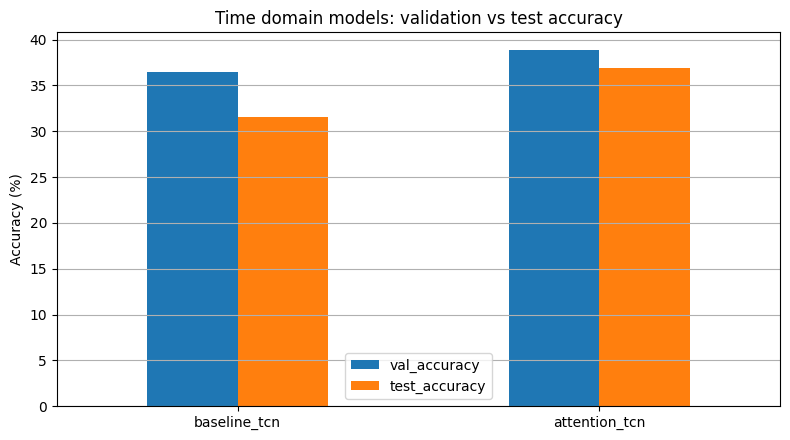

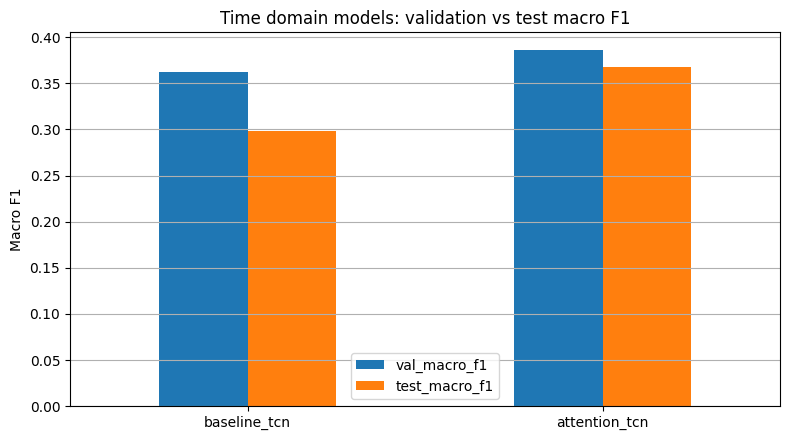

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_domain_val_test_summary.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\time_domain_val_test_summary.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_domain_val_test_accuracy.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\time_domain_val_test_accuracy.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_domain_val_test_macro_f1.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\time_domain_val_test_macro_f1.png


,model_family,result_id,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,n_params,best_config
0,baseline_tcn,baseline_tcn__trial_04,0.364865,0.315436,0.362469,0.297987,68995,"{""batch_size"": 8, ""channels"": [32, 64, 96], ""d..."
1,attention_tcn,attention_tcn__trial_16,0.388514,0.369128,0.385933,0.367776,199972,"{""att_hidden"": 32, ""batch_size"": 8, ""channels""..."


In [12]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

required_names = [
    "best_baseline",
    "best_attention",
    "best_baseline_row",
    "best_attention_row",
    "TIME_TRAIN_DIR",
    "OUT_DIR",
]

missing = [name for name in required_names if name not in globals()]
if len(missing) > 0:
    raise RuntimeError(
        f"Missing required variables from the time domain training block: {missing}"
    )

# Build a compact summary table for the final time domain results.
time_domain_summary_df = pd.DataFrame([
    {
        "model_family": "baseline_tcn",
        "result_id": str(best_baseline_row["result_id"]),
        "val_accuracy": float(best_baseline["best_val_acc"]),
        "test_accuracy": float(best_baseline["test_acc"]),
        "val_macro_f1": float(best_baseline["best_val_macro_f1"]),
        "test_macro_f1": float(best_baseline["test_macro_f1"]),
        "n_params": int(best_baseline["n_params"]),
        "best_config": json.dumps(best_baseline["cfg"], default=str),
    },
    {
        "model_family": "attention_tcn",
        "result_id": str(best_attention_row["result_id"]),
        "val_accuracy": float(best_attention["best_val_acc"]),
        "test_accuracy": float(best_attention["test_acc"]),
        "val_macro_f1": float(best_attention["best_val_macro_f1"]),
        "test_macro_f1": float(best_attention["test_macro_f1"]),
        "n_params": int(best_attention["n_params"]),
        "best_config": json.dumps(best_attention["cfg"], default=str),
    },
])

summary_csv_main = os.path.join(OUT_DIR, "time_domain_val_test_summary.csv")
summary_csv_local = os.path.join(TIME_TRAIN_DIR, "time_domain_val_test_summary.csv")

acc_png_main = os.path.join(OUT_DIR, "time_domain_val_test_accuracy.png")
acc_png_local = os.path.join(TIME_TRAIN_DIR, "time_domain_val_test_accuracy.png")

f1_png_main = os.path.join(OUT_DIR, "time_domain_val_test_macro_f1.png")
f1_png_local = os.path.join(TIME_TRAIN_DIR, "time_domain_val_test_macro_f1.png")

time_domain_summary_df.to_csv(summary_csv_main, index=False)
time_domain_summary_df.to_csv(summary_csv_local, index=False)

# Plot validation and test accuracy for the two final time domain models.
plot_df_acc = time_domain_summary_df[
    ["model_family", "val_accuracy", "test_accuracy"]
].copy()
plot_df_acc["val_accuracy"] = plot_df_acc["val_accuracy"] * 100.0
plot_df_acc["test_accuracy"] = plot_df_acc["test_accuracy"] * 100.0
plot_df_acc = plot_df_acc.set_index("model_family")

ax = plot_df_acc.plot(kind="bar", figsize=(8, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Time domain models: validation vs test accuracy")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(acc_png_main, dpi=180)
plt.savefig(acc_png_local, dpi=180)
plt.show()
plt.close()

# Plot validation and test macro F1 for the same two models.
plot_df_f1 = time_domain_summary_df[
    ["model_family", "val_macro_f1", "test_macro_f1"]
].copy()
plot_df_f1 = plot_df_f1.set_index("model_family")

ax = plot_df_f1.plot(kind="bar", figsize=(8, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Macro F1")
ax.set_title("Time domain models: validation vs test macro F1")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f1_png_main, dpi=180)
plt.savefig(f1_png_local, dpi=180)
plt.show()
plt.close()

print("Saved:", summary_csv_main)
print("Saved:", summary_csv_local)
print("Saved:", acc_png_main)
print("Saved:", acc_png_local)
print("Saved:", f1_png_main)
print("Saved:", f1_png_local)

display(time_domain_summary_df)

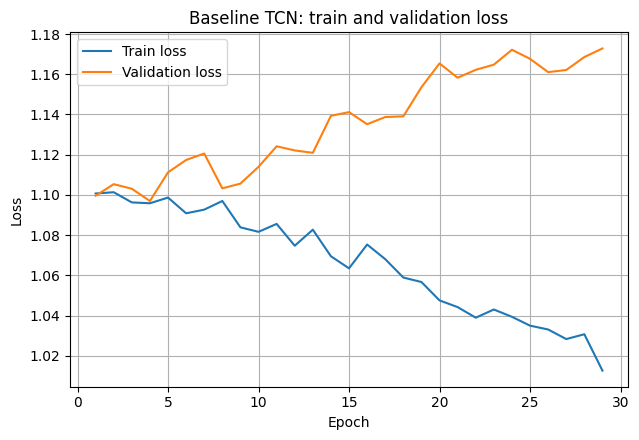

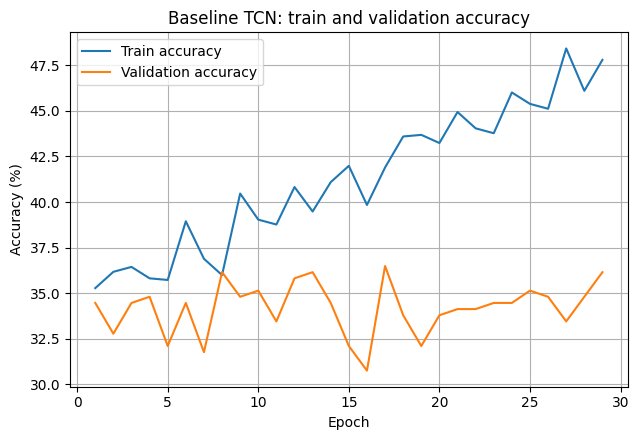

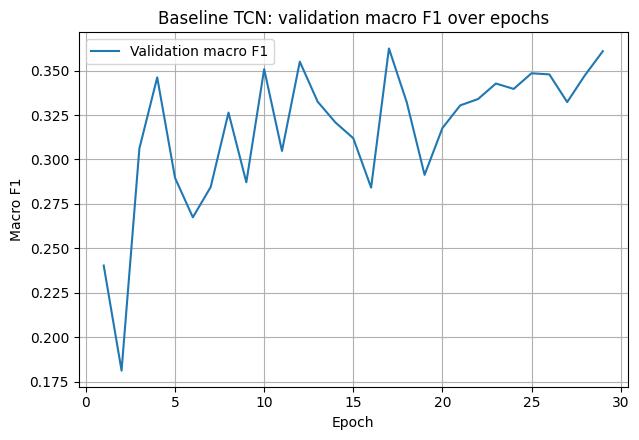

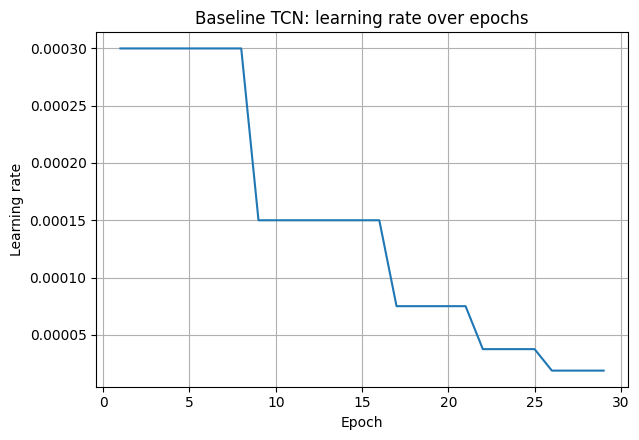

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\baseline_tcn_learning_rate_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\baseline_tcn_learning_rate_curve.png


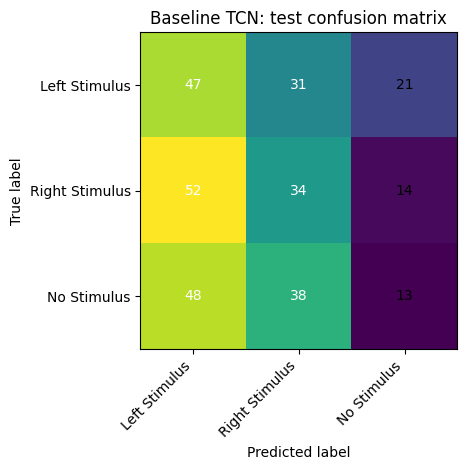

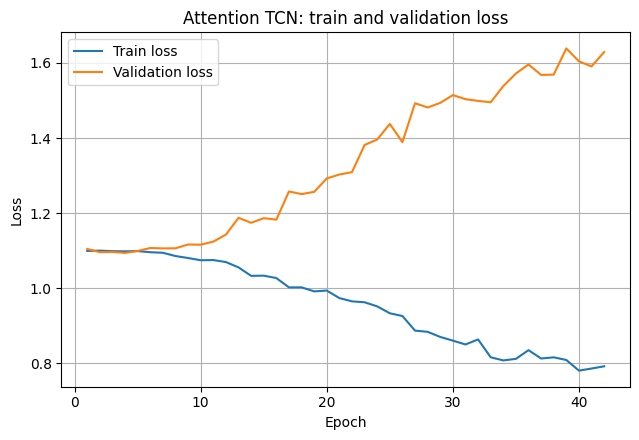

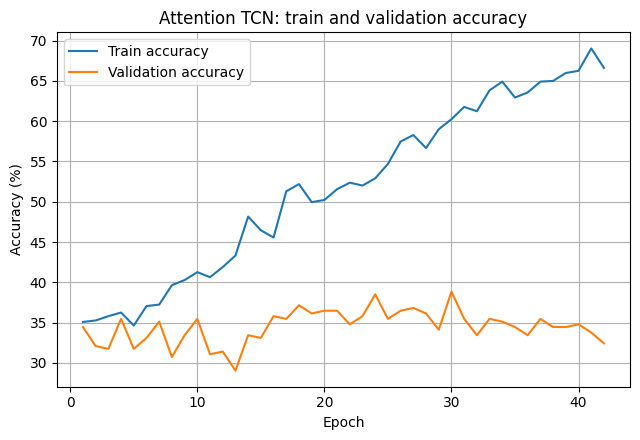

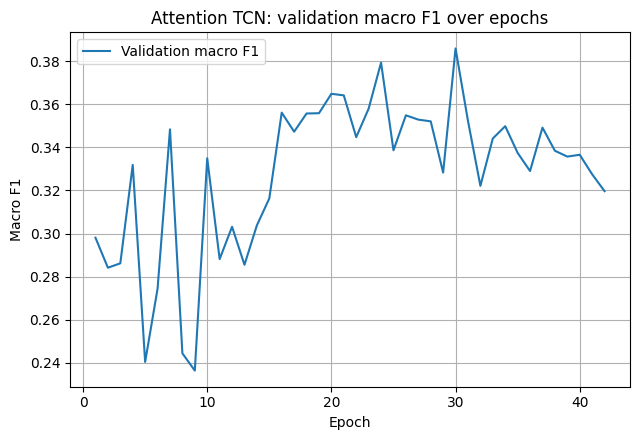

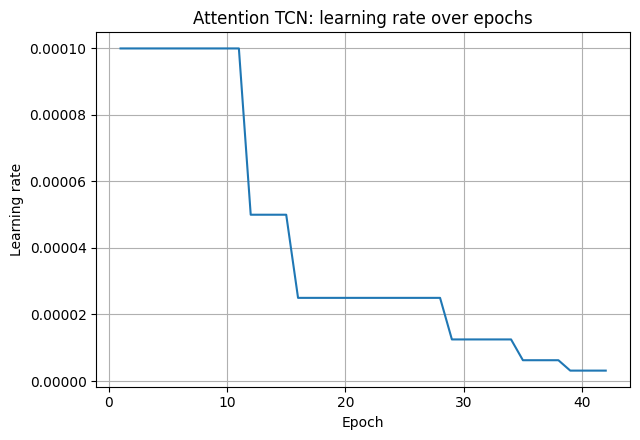

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\attention_tcn_learning_rate_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\attention_tcn_learning_rate_curve.png


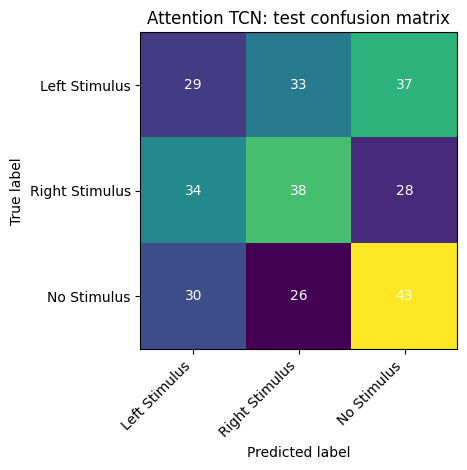

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\baseline_tcn_train_val_loss.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\baseline_tcn_train_val_loss.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\baseline_tcn_train_val_accuracy_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\baseline_tcn_train_val_accuracy_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\baseline_tcn_validation_macro_f1_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\baseline_tcn_validation_macro_f1_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\baseline_tcn_test_confusion_matrix_inline.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_domain\baseline_tcn_test_confusion_matrix_inline.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\attention_tcn_train_val_loss.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_dom

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

required_names = [
    "best_baseline",
    "best_attention",
    "TIME_TRAIN_DIR",
    "OUT_DIR",
    "CLASS_NAMES",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# Make sure the histories and final test outputs are available.
for name, obj in [("best_baseline", best_baseline), ("best_attention", best_attention)]:
    if "history" not in obj:
        raise RuntimeError(f"{name} does not contain training history.")
    if "test_eval" not in obj or "cm" not in obj["test_eval"]:
        raise RuntimeError(f"{name} does not contain test evaluation results.")

baseline_history = best_baseline["history"]
attention_history = best_attention["history"]

baseline_epochs = np.arange(1, len(baseline_history["train_loss"]) + 1)
attention_epochs = np.arange(1, len(attention_history["train_loss"]) + 1)

# Plot train and validation loss for the baseline model.
baseline_loss_png_main = os.path.join(OUT_DIR, "baseline_tcn_train_val_loss.png")
baseline_loss_png_local = os.path.join(TIME_TRAIN_DIR, "baseline_tcn_train_val_loss.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(baseline_epochs, baseline_history["train_loss"], label="Train loss")
plt.plot(baseline_epochs, baseline_history["val_loss"], label="Validation loss")
plt.title("Baseline TCN: train and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(baseline_loss_png_main, dpi=180)
plt.savefig(baseline_loss_png_local, dpi=180)
plt.show()
plt.close()

# Plot train and validation accuracy for the baseline model.
baseline_acc_curve_png_main = os.path.join(OUT_DIR, "baseline_tcn_train_val_accuracy_curve.png")
baseline_acc_curve_png_local = os.path.join(TIME_TRAIN_DIR, "baseline_tcn_train_val_accuracy_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(baseline_epochs, np.array(baseline_history["train_acc"]) * 100.0, label="Train accuracy")
plt.plot(baseline_epochs, np.array(baseline_history["val_acc"]) * 100.0, label="Validation accuracy")
plt.title("Baseline TCN: train and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(baseline_acc_curve_png_main, dpi=180)
plt.savefig(baseline_acc_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot validation macro F1 for the baseline model.
baseline_f1_curve_png_main = os.path.join(OUT_DIR, "baseline_tcn_validation_macro_f1_curve.png")
baseline_f1_curve_png_local = os.path.join(TIME_TRAIN_DIR, "baseline_tcn_validation_macro_f1_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(baseline_epochs, baseline_history["val_macro_f1"], label="Validation macro F1")
plt.title("Baseline TCN: validation macro F1 over epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(baseline_f1_curve_png_main, dpi=180)
plt.savefig(baseline_f1_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot the learning rate for the baseline model if it is available.
if "lr" in baseline_history and len(baseline_history["lr"]) > 0:
    baseline_lr_png_main = os.path.join(OUT_DIR, "baseline_tcn_learning_rate_curve.png")
    baseline_lr_png_local = os.path.join(TIME_TRAIN_DIR, "baseline_tcn_learning_rate_curve.png")

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(baseline_epochs, baseline_history["lr"])
    plt.title("Baseline TCN: learning rate over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(baseline_lr_png_main, dpi=180)
    plt.savefig(baseline_lr_png_local, dpi=180)
    plt.show()
    plt.close()

    print("Saved:", baseline_lr_png_main)
    print("Saved:", baseline_lr_png_local)

# Plot the confusion matrix for the baseline model.
baseline_cm = best_baseline["test_eval"]["cm"]
baseline_cm_png_main = os.path.join(OUT_DIR, "baseline_tcn_test_confusion_matrix_inline.png")
baseline_cm_png_local = os.path.join(TIME_TRAIN_DIR, "baseline_tcn_test_confusion_matrix_inline.png")

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.imshow(baseline_cm, interpolation="nearest")
ax.set_title("Baseline TCN: test confusion matrix")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

thresh = baseline_cm.max() / 2.0 if baseline_cm.size else 0.0
for i in range(baseline_cm.shape[0]):
    for j in range(baseline_cm.shape[1]):
        ax.text(
            j, i, str(baseline_cm[i, j]),
            ha="center", va="center",
            color="white" if baseline_cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.savefig(baseline_cm_png_main, dpi=180)
plt.savefig(baseline_cm_png_local, dpi=180)
plt.show()
plt.close()

# Plot train and validation loss for the attention model.
attention_loss_png_main = os.path.join(OUT_DIR, "attention_tcn_train_val_loss.png")
attention_loss_png_local = os.path.join(TIME_TRAIN_DIR, "attention_tcn_train_val_loss.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(attention_epochs, attention_history["train_loss"], label="Train loss")
plt.plot(attention_epochs, attention_history["val_loss"], label="Validation loss")
plt.title("Attention TCN: train and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(attention_loss_png_main, dpi=180)
plt.savefig(attention_loss_png_local, dpi=180)
plt.show()
plt.close()

# Plot train and validation accuracy for the attention model.
attention_acc_curve_png_main = os.path.join(OUT_DIR, "attention_tcn_train_val_accuracy_curve.png")
attention_acc_curve_png_local = os.path.join(TIME_TRAIN_DIR, "attention_tcn_train_val_accuracy_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(attention_epochs, np.array(attention_history["train_acc"]) * 100.0, label="Train accuracy")
plt.plot(attention_epochs, np.array(attention_history["val_acc"]) * 100.0, label="Validation accuracy")
plt.title("Attention TCN: train and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(attention_acc_curve_png_main, dpi=180)
plt.savefig(attention_acc_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot validation macro F1 for the attention model.
attention_f1_curve_png_main = os.path.join(OUT_DIR, "attention_tcn_validation_macro_f1_curve.png")
attention_f1_curve_png_local = os.path.join(TIME_TRAIN_DIR, "attention_tcn_validation_macro_f1_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(attention_epochs, attention_history["val_macro_f1"], label="Validation macro F1")
plt.title("Attention TCN: validation macro F1 over epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(attention_f1_curve_png_main, dpi=180)
plt.savefig(attention_f1_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot the learning rate for the attention model if it is available.
if "lr" in attention_history and len(attention_history["lr"]) > 0:
    attention_lr_png_main = os.path.join(OUT_DIR, "attention_tcn_learning_rate_curve.png")
    attention_lr_png_local = os.path.join(TIME_TRAIN_DIR, "attention_tcn_learning_rate_curve.png")

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(attention_epochs, attention_history["lr"])
    plt.title("Attention TCN: learning rate over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(attention_lr_png_main, dpi=180)
    plt.savefig(attention_lr_png_local, dpi=180)
    plt.show()
    plt.close()

    print("Saved:", attention_lr_png_main)
    print("Saved:", attention_lr_png_local)

# Plot the confusion matrix for the attention model.
attention_cm = best_attention["test_eval"]["cm"]
attention_cm_png_main = os.path.join(OUT_DIR, "attention_tcn_test_confusion_matrix_inline.png")
attention_cm_png_local = os.path.join(TIME_TRAIN_DIR, "attention_tcn_test_confusion_matrix_inline.png")

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.imshow(attention_cm, interpolation="nearest")
ax.set_title("Attention TCN: test confusion matrix")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

thresh = attention_cm.max() / 2.0 if attention_cm.size else 0.0
for i in range(attention_cm.shape[0]):
    for j in range(attention_cm.shape[1]):
        ax.text(
            j, i, str(attention_cm[i, j]),
            ha="center", va="center",
            color="white" if attention_cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.savefig(attention_cm_png_main, dpi=180)
plt.savefig(attention_cm_png_local, dpi=180)
plt.show()
plt.close()

print("Saved:", baseline_loss_png_main)
print("Saved:", baseline_loss_png_local)
print("Saved:", baseline_acc_curve_png_main)
print("Saved:", baseline_acc_curve_png_local)
print("Saved:", baseline_f1_curve_png_main)
print("Saved:", baseline_f1_curve_png_local)
print("Saved:", baseline_cm_png_main)
print("Saved:", baseline_cm_png_local)
print("Saved:", attention_loss_png_main)
print("Saved:", attention_loss_png_local)
print("Saved:", attention_acc_curve_png_main)
print("Saved:", attention_acc_curve_png_local)
print("Saved:", attention_f1_curve_png_main)
print("Saved:", attention_f1_curve_png_local)
print("Saved:", attention_cm_png_main)
print("Saved:", attention_cm_png_local)

In [10]:
import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.model_selection import ParameterGrid

# Set the random seeds for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

FREQ_TRAIN_DIR = os.path.join(OUT_DIR, "training_time_frequency")
os.makedirs(FREQ_TRAIN_DIR, exist_ok=True)

FREQ_CKPT_DIR = os.path.join(FREQ_TRAIN_DIR, "trial_checkpoints")
os.makedirs(FREQ_CKPT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_classes = int(len(np.unique(y_train)))
CLASS_NAMES = ["Left Stimulus", "Right Stimulus", "No Stimulus"]

print("Device:", device)
print("n_classes:", n_classes)
print("X_freq_train shape:", X_freq_train.shape)
print("X_freq_val shape:", X_freq_val.shape)
print("X_freq_test shape:", X_freq_test.shape)


class NumpyDataset4D(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32, copy=False)
        self.y = y.astype(np.int64, copy=False)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(int(self.y[idx]), dtype=torch.long)


def make_weighted_sampler(y_arr, n_classes):
    y_arr = np.asarray(y_arr, dtype=np.int64)
    counts = np.bincount(y_arr, minlength=n_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    class_w = 1.0 / counts
    sample_w = class_w[y_arr]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True
    )


train_ds = NumpyDataset4D(X_freq_train, y_train)
val_ds = NumpyDataset4D(X_freq_val, y_val)
test_ds = NumpyDataset4D(X_freq_test, y_test)


def make_loaders(batch_size=16):
    train_loader = DataLoader(
        train_ds,
        batch_size=int(batch_size),
        sampler=make_weighted_sampler(y_train, n_classes),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=int(batch_size),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=int(batch_size),
        shuffle=False,
        drop_last=False,
        num_workers=0
    )
    return train_loader, val_loader, test_loader


class SpectrogramCNN(nn.Module):
    def __init__(self, in_channels, n_classes=3, base_channels=32, p_drop=0.30):
        super().__init__()
        c1 = int(base_channels)
        c2 = int(base_channels) * 2
        c3 = int(base_channels) * 4

        self.conv1 = nn.Conv2d(in_channels, c1, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(c1)

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(c2)

        self.conv3 = nn.Conv2d(c2, c3, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(c3)

        # Pool only across frequency.
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.drop = nn.Dropout(float(p_drop))
        self.fc = nn.Linear(c3, n_classes)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = F.gelu(self.bn3(self.conv3(x)))

        x = self.gap(x).squeeze(-1).squeeze(-1)
        x = self.drop(x)
        return self.fc(x)


def build_model(cfg):
    return SpectrogramCNN(
        in_channels=X_freq_train.shape[1],
        n_classes=n_classes,
        base_channels=int(cfg["base_channels"]),
        p_drop=float(cfg["dropout"]),
    )


def evaluate_model(model, loader, device, criterion=None):
    model.eval()

    all_preds, all_true = [], []
    running_loss = 0.0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)

            if criterion is not None:
                loss = criterion(logits, yb)
                running_loss += loss.item() * yb.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_true.extend(yb.detach().cpu().numpy().tolist())
            total += yb.size(0)

    all_preds = np.array(all_preds, dtype=np.int64)
    all_true = np.array(all_true, dtype=np.int64)

    labels = list(range(n_classes))
    return {
        "loss": running_loss / max(1, total) if criterion is not None else np.nan,
        "acc": accuracy_score(all_true, all_preds),
        "macro_f1": f1_score(all_true, all_preds, average="macro"),
        "preds": all_preds,
        "true": all_true,
        "cm": confusion_matrix(all_true, all_preds, labels=labels),
        "report_text": classification_report(
            all_true, all_preds,
            labels=labels,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        ),
    }


def plot_confusion(cm, class_names, title, out_png):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True")
    ax.set_xlabel("Pred")

    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)


def plot_history(history, title_prefix, out_png):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train loss")
    axes[0].plot(epochs, history["val_loss"], label="Val loss")
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, np.array(history["train_acc"]) * 100, label="Train acc")
    axes[1].plot(epochs, np.array(history["val_acc"]) * 100, label="Val acc")
    axes[1].set_title(f"{title_prefix} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(epochs, history["val_macro_f1"], label="Val macro-F1")
    axes[2].set_title(f"{title_prefix} - Val Macro-F1")
    axes[2].set_xlabel("Epoch")
    axes[2].grid(True)
    axes[2].legend()

    fig.tight_layout()
    fig.savefig(out_png, dpi=180)
    plt.close(fig)


def train_one_configuration(cfg, result_id, max_epochs=80, patience=10):
    batch_size = int(cfg["batch_size"])
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)

    model = build_model(cfg).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=float(cfg.get("label_smoothing", 0.05)))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"])
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_val_f1 = -1.0
    best_state = None
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": [],
    }

    for epoch in range(1, max_epochs + 1):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss / max(1, total)
        train_acc = correct / max(1, total)

        val_eval = evaluate_model(model, val_loader, device, criterion=criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_eval["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_eval["acc"])
        history["val_macro_f1"].append(val_eval["macro_f1"])
        history["lr"].append(float(optimizer.param_groups[0]["lr"]))

        scheduler.step(val_eval["macro_f1"])

        if val_eval["macro_f1"] > best_val_f1 + 1e-4:
            best_val_f1 = val_eval["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is None:
        raise RuntimeError(f"No best_state captured for {result_id}")

    state_path = os.path.join(FREQ_CKPT_DIR, f"{result_id}.pt")
    torch.save(
        {
            "cfg": dict(cfg),
            "state_dict": best_state,
        },
        state_path
    )

    final_val_model = build_model(cfg).to(device)
    final_val_model.load_state_dict(best_state)
    val_eval = evaluate_model(final_val_model, val_loader, device, criterion=criterion)

    result = {
        "result_id": result_id,
        "cfg": dict(cfg),
        "history": history,
        "best_val_macro_f1": float(val_eval["macro_f1"]),
        "best_val_acc": float(val_eval["acc"]),
        "val_eval": val_eval,
        "n_params": int(sum(p.numel() for p in final_val_model.parameters() if p.requires_grad)),
        "state_path": state_path,
    }

    del model
    del final_val_model
    del best_state
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return result


SEARCH_REPORT_DIR = os.path.join(FREQ_TRAIN_DIR, "search_design")
os.makedirs(SEARCH_REPORT_DIR, exist_ok=True)

RUN_FULL_GRID = False
MAX_TRIALS = 16

full_grid_all = list(ParameterGrid({
    "base_channels": [16, 32],
    "dropout": [0.20, 0.30],
    "lr": [1e-4, 3e-4],
    "weight_decay": [1e-4, 1e-3],
    "batch_size": [16, 32],
    "label_smoothing": [0.05],
}))

full_grid_df = pd.DataFrame(full_grid_all)
full_grid_csv = os.path.join(SEARCH_REPORT_DIR, "spectrogram_cnn_full_grid.csv")
full_grid_df.to_csv(full_grid_csv, index=False)


def _sample_grid(grid, n_keep, rng):
    if n_keep >= len(grid):
        return list(grid)
    chosen = sorted(rng.choice(len(grid), size=n_keep, replace=False).tolist())
    return [grid[i] for i in chosen]


rng = np.random.default_rng(SEED)

if RUN_FULL_GRID:
    full_grid = list(full_grid_all)
else:
    full_grid = _sample_grid(full_grid_all, MAX_TRIALS, rng)

sampled_grid_df = pd.DataFrame(full_grid)
sampled_grid_csv = os.path.join(SEARCH_REPORT_DIR, "spectrogram_cnn_sampled_grid.csv")
sampled_grid_df.to_csv(sampled_grid_csv, index=False)

with open(os.path.join(SEARCH_REPORT_DIR, "time_frequency_search_design_summary.json"), "w", encoding="utf-8") as f:
    json.dump({
        "run_full_grid": bool(RUN_FULL_GRID),
        "full_grid_size": int(len(full_grid_all)),
        "requested_trials_if_sampled": int(MAX_TRIALS),
        "actual_trials_to_run": int(len(full_grid)),
        "seed": int(SEED),
        "note": "The sampled subset is deterministic given SEED. The full grid is saved for reference."
    }, f, indent=2)

print("Spectrogram full grid size:", len(full_grid_all))
print("Spectrogram trials to run :", len(full_grid))
print("\nSaved search-design artifacts:")
print(" -", full_grid_csv)
print(" -", sampled_grid_csv)
print(" -", os.path.join(SEARCH_REPORT_DIR, "time_frequency_search_design_summary.json"))


all_results = []

for trial_idx, cfg in enumerate(full_grid, start=1):
    result_id = f"spec_trial_{trial_idx:03d}"

    print(f"\n[SpectrogramCNN] trial {trial_idx}/{len(full_grid)} | cfg={cfg}")
    t0 = time.time()

    res = train_one_configuration(
        cfg=cfg,
        result_id=result_id,
        max_epochs=80,
        patience=10
    )

    elapsed_s = time.time() - t0

    row = {
        "result_id": result_id,
        "trial_idx": int(trial_idx),
        "base_channels": int(cfg["base_channels"]),
        "dropout": float(cfg["dropout"]),
        "lr": float(cfg["lr"]),
        "weight_decay": float(cfg["weight_decay"]),
        "batch_size": int(cfg["batch_size"]),
        "label_smoothing": float(cfg["label_smoothing"]),
        "n_params": int(res["n_params"]),
        "best_val_macro_f1": float(res["best_val_macro_f1"]),
        "best_val_acc": float(res["best_val_acc"]),
        "elapsed_s": float(elapsed_s),
        "state_path": res["state_path"],
    }

    all_results.append({
        "result_id": result_id,
        "row": row,
        "full_result": res
    })

    print(
        f" -> val_macroF1={row['best_val_macro_f1']:.4f} | "
        f"val_acc={row['best_val_acc']*100:.2f}% | "
        f"params={row['n_params']}"
    )

if len(all_results) == 0:
    raise RuntimeError("No frequency-domain trials were completed.")

search_rows = [x["row"] for x in all_results]
search_df = pd.DataFrame(search_rows).sort_values(
    ["best_val_macro_f1", "best_val_acc"],
    ascending=[False, False]
).reset_index(drop=True)

search_csv = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_hparam_search_results.csv")
search_df.to_csv(search_csv, index=False)
print("\nSaved:", search_csv)


best_result_id = str(search_df.iloc[0]["result_id"])
best_res = None

for item in all_results:
    if item["result_id"] == best_result_id:
        best_res = item["full_result"]
        break

if best_res is None:
    raise RuntimeError(f"Could not recover best SpectrogramCNN search result for result_id={best_result_id}")


def _load_model_from_checkpoint(cfg, state_path):
    ckpt = torch.load(state_path, map_location="cpu")
    model = build_model(cfg)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(device)
    model.eval()
    return model


_, val_loader_ref, test_loader_ref = make_loaders(batch_size=16)

best_model = _load_model_from_checkpoint(
    best_res["cfg"],
    best_res["state_path"]
)

best_val_eval_final = evaluate_model(best_model, val_loader_ref, device, criterion=None)
best_test_eval = evaluate_model(best_model, test_loader_ref, device, criterion=None)

best_res["val_eval_final"] = best_val_eval_final
best_res["test_eval"] = best_test_eval
best_res["test_macro_f1"] = float(best_test_eval["macro_f1"])
best_res["test_acc"] = float(best_test_eval["acc"])


plot_history(
    best_res["history"],
    title_prefix="Best SpectrogramCNN",
    out_png=os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_history.png")
)

plot_confusion(
    best_res["test_eval"]["cm"],
    class_names=CLASS_NAMES,
    title="Best SpectrogramCNN - Test Confusion Matrix",
    out_png=os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_test_confusion.png")
)

with open(os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_report.txt"), "w", encoding="utf-8") as f:
    f.write(best_res["test_eval"]["report_text"])

with open(os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_summary.json"), "w", encoding="utf-8") as f:
    json.dump({
        "result_id": best_result_id,
        "best_val_macro_f1": float(best_res["best_val_macro_f1"]),
        "best_val_acc": float(best_res["best_val_acc"]),
        "final_test_macro_f1": float(best_res["test_macro_f1"]),
        "final_test_acc": float(best_res["test_acc"]),
        "n_params": int(best_res["n_params"]),
        "cfg": best_res["cfg"],
        "state_path": best_res["state_path"],
    }, f, indent=2)

print("\nFinal time-frequency summary")
print("Best SpectrogramCNN:")
print("  result_id          =", best_result_id)
print("  val_macroF1        =", best_res["best_val_macro_f1"])
print("  val_acc            = {:.2f}%".format(best_res["best_val_acc"] * 100))
print("  final_test_macroF1 =", best_res["test_macro_f1"])
print("  final_test_acc     = {:.2f}%".format(best_res["test_acc"] * 100))
print("  cfg                =", best_res["cfg"])

print("\nSaved:")
print(" -", search_csv)
print(" -", os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_history.png"))
print(" -", os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_test_confusion.png"))
print(" -", os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_report.txt"))
print(" -", os.path.join(FREQ_TRAIN_DIR, "best_spectrogram_cnn_summary.json"))
print(" - checkpoints in:", FREQ_CKPT_DIR)
print(" - search-design artifacts in:", SEARCH_REPORT_DIR)

Device: cpu
n_classes: 3
X_freq_train shape: (1117, 64, 481, 8)
X_freq_val shape: (296, 64, 481, 8)
X_freq_test shape: (298, 64, 481, 8)
Spectrogram full grid size: 32
Spectrogram trials to run : 16

Saved search-design artifacts:
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\search_design\spectrogram_cnn_full_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\search_design\spectrogram_cnn_sampled_grid.csv
 - D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\search_design\time_frequency_search_design_summary.json

[SpectrogramCNN] trial 1/16 | cfg={'base_channels': 16, 'batch_size': 16, 'dropout': 0.2, 'label_smoothing': 0.05, 'lr': 0.0001, 'weight_decay': 0.001}
 -> val_macroF1=0.3662 | val_acc=38.18% | params=32787

[SpectrogramCNN] trial 2/16 | cfg={'base_channels': 16, 'batch_size': 16, 'dropout': 0.2, 'label_smoothing': 0.05, 'lr': 0.0003, 'weight_decay': 0.0001}
 -> val_macroF1=0.3889 | val_acc=38.85

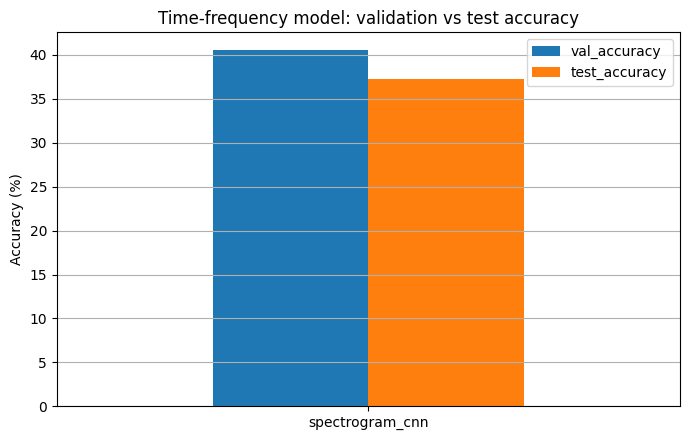

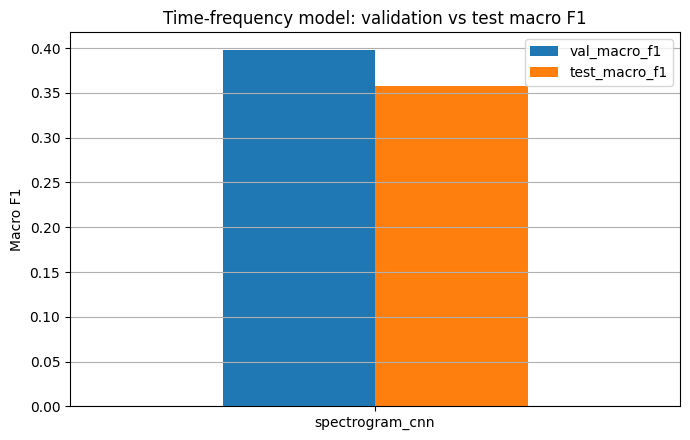

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_frequency_val_test_summary.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\time_frequency_val_test_summary.csv
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_frequency_val_test_accuracy.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\time_frequency_val_test_accuracy.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\time_frequency_val_test_macro_f1.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\time_frequency_val_test_macro_f1.png


,model_family,result_id,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,n_params,best_config
0,spectrogram_cnn,spec_trial_010,0.405405,0.372483,0.397839,0.357425,111651,"{""base_channels"": 32, ""batch_size"": 16, ""dropo..."


In [14]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

required_names = [
    "best_res",
    "best_result_id",
    "FREQ_TRAIN_DIR",
    "OUT_DIR",
]

missing = [name for name in required_names if name not in globals()]
if len(missing) > 0:
    raise RuntimeError(
        f"Missing required variables from the time-frequency training block: {missing}"
    )

# Build a compact summary table for the final time-frequency result.
time_frequency_summary_df = pd.DataFrame([
    {
        "model_family": "spectrogram_cnn",
        "result_id": str(best_result_id),
        "val_accuracy": float(best_res["best_val_acc"]),
        "test_accuracy": float(best_res["test_acc"]),
        "val_macro_f1": float(best_res["best_val_macro_f1"]),
        "test_macro_f1": float(best_res["test_macro_f1"]),
        "n_params": int(best_res["n_params"]),
        "best_config": json.dumps(best_res["cfg"], default=str),
    }
])

summary_csv_main = os.path.join(OUT_DIR, "time_frequency_val_test_summary.csv")
summary_csv_local = os.path.join(FREQ_TRAIN_DIR, "time_frequency_val_test_summary.csv")

acc_png_main = os.path.join(OUT_DIR, "time_frequency_val_test_accuracy.png")
acc_png_local = os.path.join(FREQ_TRAIN_DIR, "time_frequency_val_test_accuracy.png")

f1_png_main = os.path.join(OUT_DIR, "time_frequency_val_test_macro_f1.png")
f1_png_local = os.path.join(FREQ_TRAIN_DIR, "time_frequency_val_test_macro_f1.png")

time_frequency_summary_df.to_csv(summary_csv_main, index=False)
time_frequency_summary_df.to_csv(summary_csv_local, index=False)

# Plot validation and test accuracy for the final time-frequency model.
plot_df_acc = time_frequency_summary_df[
    ["model_family", "val_accuracy", "test_accuracy"]
].copy()
plot_df_acc["val_accuracy"] = plot_df_acc["val_accuracy"] * 100.0
plot_df_acc["test_accuracy"] = plot_df_acc["test_accuracy"] * 100.0
plot_df_acc = plot_df_acc.set_index("model_family")

ax = plot_df_acc.plot(kind="bar", figsize=(7, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Time-frequency model: validation vs test accuracy")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(acc_png_main, dpi=180)
plt.savefig(acc_png_local, dpi=180)
plt.show()
plt.close()

# Plot validation and test macro F1 for the final time-frequency model.
plot_df_f1 = time_frequency_summary_df[
    ["model_family", "val_macro_f1", "test_macro_f1"]
].copy()
plot_df_f1 = plot_df_f1.set_index("model_family")

ax = plot_df_f1.plot(kind="bar", figsize=(7, 4.5))
ax.set_xlabel("")
ax.set_ylabel("Macro F1")
ax.set_title("Time-frequency model: validation vs test macro F1")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f1_png_main, dpi=180)
plt.savefig(f1_png_local, dpi=180)
plt.show()
plt.close()

print("Saved:", summary_csv_main)
print("Saved:", summary_csv_local)
print("Saved:", acc_png_main)
print("Saved:", acc_png_local)
print("Saved:", f1_png_main)
print("Saved:", f1_png_local)

display(time_frequency_summary_df)

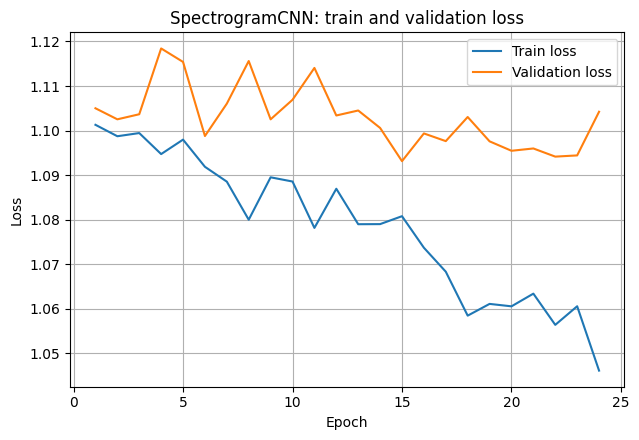

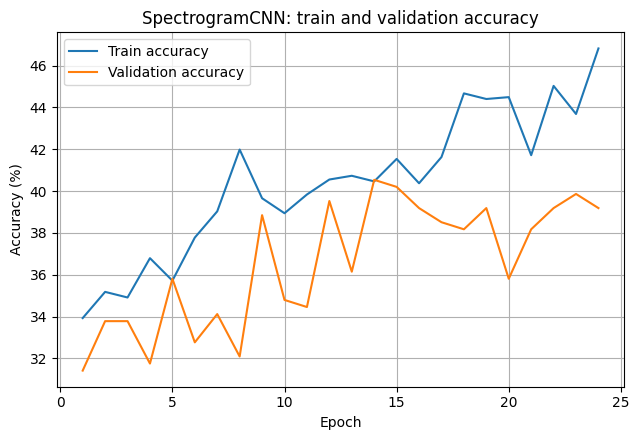

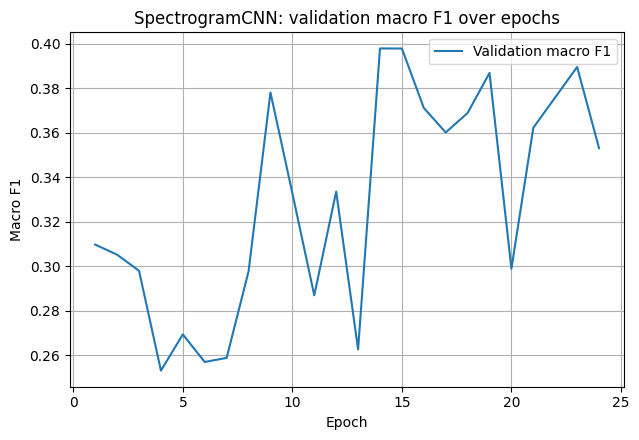

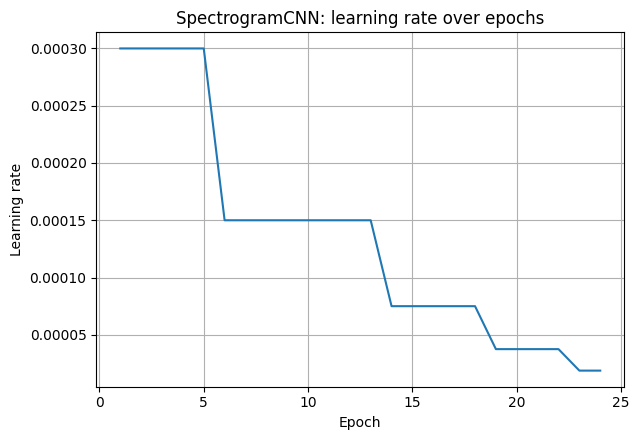

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\spectrogram_cnn_learning_rate_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\spectrogram_cnn_learning_rate_curve.png


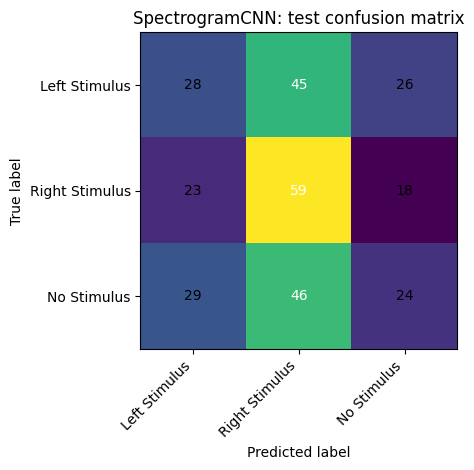

Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\spectrogram_cnn_train_val_loss.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\spectrogram_cnn_train_val_loss.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\spectrogram_cnn_train_val_accuracy_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\spectrogram_cnn_train_val_accuracy_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\spectrogram_cnn_validation_macro_f1_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\spectrogram_cnn_validation_macro_f1_curve.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\spectrogram_cnn_test_confusion_matrix_inline.png
Saved: D:\EEG_CleanSegments_And_Datasets_block1_theta\training_time_frequency\spectrogram_cnn_test_confusion_matrix_inline.png


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

required_names = [
    "best_res",
    "FREQ_TRAIN_DIR",
    "OUT_DIR",
    "CLASS_NAMES",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# Make sure the required history and final test outputs are available.
if "history" not in best_res:
    raise RuntimeError("best_res does not contain training history.")
if "test_eval" not in best_res or "cm" not in best_res["test_eval"]:
    raise RuntimeError("best_res does not contain test evaluation results.")

history = best_res["history"]
epochs = np.arange(1, len(history["train_loss"]) + 1)

# Plot train and validation loss.
loss_png_main = os.path.join(OUT_DIR, "spectrogram_cnn_train_val_loss.png")
loss_png_local = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_train_val_loss.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.title("SpectrogramCNN: train and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_png_main, dpi=180)
plt.savefig(loss_png_local, dpi=180)
plt.show()
plt.close()

# Plot train and validation accuracy.
acc_curve_png_main = os.path.join(OUT_DIR, "spectrogram_cnn_train_val_accuracy_curve.png")
acc_curve_png_local = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_train_val_accuracy_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(epochs, np.array(history["train_acc"]) * 100.0, label="Train accuracy")
plt.plot(epochs, np.array(history["val_acc"]) * 100.0, label="Validation accuracy")
plt.title("SpectrogramCNN: train and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(acc_curve_png_main, dpi=180)
plt.savefig(acc_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot validation macro F1.
f1_curve_png_main = os.path.join(OUT_DIR, "spectrogram_cnn_validation_macro_f1_curve.png")
f1_curve_png_local = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_validation_macro_f1_curve.png")

plt.figure(figsize=(6.5, 4.5))
plt.plot(epochs, history["val_macro_f1"], label="Validation macro F1")
plt.title("SpectrogramCNN: validation macro F1 over epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f1_curve_png_main, dpi=180)
plt.savefig(f1_curve_png_local, dpi=180)
plt.show()
plt.close()

# Plot the learning rate if it is available.
if "lr" in history and len(history["lr"]) > 0:
    lr_png_main = os.path.join(OUT_DIR, "spectrogram_cnn_learning_rate_curve.png")
    lr_png_local = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_learning_rate_curve.png")

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(epochs, history["lr"])
    plt.title("SpectrogramCNN: learning rate over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(lr_png_main, dpi=180)
    plt.savefig(lr_png_local, dpi=180)
    plt.show()
    plt.close()

    print("Saved:", lr_png_main)
    print("Saved:", lr_png_local)

# Plot the confusion matrix.
cm = best_res["test_eval"]["cm"]
cm_png_main = os.path.join(OUT_DIR, "spectrogram_cnn_test_confusion_matrix_inline.png")
cm_png_local = os.path.join(FREQ_TRAIN_DIR, "spectrogram_cnn_test_confusion_matrix_inline.png")

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.imshow(cm, interpolation="nearest")
ax.set_title("SpectrogramCNN: test confusion matrix")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

thresh = cm.max() / 2.0 if cm.size else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.savefig(cm_png_main, dpi=180)
plt.savefig(cm_png_local, dpi=180)
plt.show()
plt.close()

print("Saved:", loss_png_main)
print("Saved:", loss_png_local)
print("Saved:", acc_curve_png_main)
print("Saved:", acc_curve_png_local)
print("Saved:", f1_curve_png_main)
print("Saved:", f1_curve_png_local)
print("Saved:", cm_png_main)
print("Saved:", cm_png_local)